# State of Data 2023–2025: análise da camada Gold

**Tech Challenge — Data Analytics | FIAP**

Este é um notebook analítico independente, cujo ponto de partida são exclusivamente os 12 arquivos CSV exportados das tabelas Gold no Amazon Athena.

Ele não executa nem depende dos tratamentos das camadas Bronze e Silver. Seu objetivo é transformar os dados Gold já estruturados em evidências sobre competências, carreira, remuneração, satisfação, diversidade e modelos de trabalho no mercado brasileiro de Dados.

## 1. Instalação das bibliotecas

A primeira célula concentra as dependências utilizadas. No Google Colab, execute-a uma vez antes das demais.

In [7]:
# Instala as bibliotecas utilizadas na análise e nos gráficos
%pip -q install "pandas>=2.0,<3.0" "matplotlib>=3.7,<4.0" "seaborn>=0.13,<0.14"

## 2. Configuração do ambiente

O código funciona tanto no Google Colab quanto em um repositório local. No Colab, ele procura primeiro os arquivos dentro do Google Drive e depois em `/content`.

In [8]:
# Importa bibliotecas de manipulação de dados, caminhos e visualização
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

# Identifica se o notebook está sendo executado no Google Colab
try:
    from google.colab import drive
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    drive.mount("/content/drive")

arquivo_referencia = "fiap_state_of_data.gold_mercado.csv"

# Primeiro verifica os caminhos mais comuns, que são mais rápidos.
caminhos_candidatos = [
    Path("/content/drive/MyDrive/Tech_Challenge_Fase_3/data/athena_results"),
    Path("/content/drive/MyDrive/Tech_Challenge_Fase_3/data/gold"),
    Path("/content/drive/MyDrive/Tech Challenge Fase 3/data/gold"),
    Path("/content"),
    Path.cwd() / "data" / "gold",
    Path.cwd(),
]

DATA_DIR = next(
    (pasta for pasta in caminhos_candidatos if (pasta / arquivo_referencia).exists()),
    None,
)

# Caso o nome ou a posição da pasta seja diferente, procura o arquivo no Drive.
if DATA_DIR is None and EM_COLAB:
    raizes_busca = [Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives")]
    arquivos_encontrados = []
    for raiz in raizes_busca:
        if raiz.exists():
            arquivos_encontrados.extend(raiz.rglob(arquivo_referencia))

    if arquivos_encontrados:
        DATA_DIR = arquivos_encontrados[0].parent
        if len(arquivos_encontrados) > 1:
            print("Atenção: mais de uma cópia da tabela Gold foi encontrada.")
            print("Será utilizada:", arquivos_encontrados[0])

if DATA_DIR is None:
    raise FileNotFoundError(
        "Os CSVs Gold não foram encontrados no Google Drive. "
        "Confirme se a pasta data/gold contém o arquivo "
        f"{arquivo_referencia}."
    )

# Salva os gráficos na pasta outputs do mesmo projeto que contém data/gold.
if EM_COLAB and DATA_DIR.name == "gold" and DATA_DIR.parent.name == "data":
    PROJECT_DIR = DATA_DIR.parent.parent
    OUTPUT_DIR = PROJECT_DIR / "outputs" / "graficos_gold"
elif EM_COLAB:
    OUTPUT_DIR = DATA_DIR.parent / "outputs" / "graficos_gold"
else:
    OUTPUT_DIR = Path.cwd() / "outputs" / "graficos_gold"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Pasta dos dados encontrada:", DATA_DIR)
print("Pasta dos gráficos:", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pasta dos dados encontrada: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/data/gold
Pasta dos gráficos: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold


## 3. Leitura das 12 tabelas Gold

Cada arquivo mantém o nome da tabela de origem no Glue Data Catalog e no Athena.

In [9]:
# Relaciona o nome lógico de cada dataset ao respectivo arquivo exportado do Athena
arquivos_gold = {
    "diversidade": "fiap_state_of_data.gold_diversidade.csv",
    "experiencia": "fiap_state_of_data.gold_experiencia.csv",
    "formacao": "fiap_state_of_data.gold_formacao.csv",
    "geografia": "fiap_state_of_data.gold_geografia.csv",
    "ia": "fiap_state_of_data.gold_ia.csv",
    "indicadores_anuais": "fiap_state_of_data.gold_indicadores_anuais.csv",
    "mercado": "fiap_state_of_data.gold_mercado.csv",
    "modelo_trabalho": "fiap_state_of_data.gold_modelo_trabalho.csv",
    "remuneracao": "fiap_state_of_data.gold_remuneracao.csv",
    "satisfacao": "fiap_state_of_data.gold_satisfacao.csv",
    "setores": "fiap_state_of_data.gold_setores.csv",
    "tecnologias": "fiap_state_of_data.gold_tecnologias.csv",
}

# Carrega todos os arquivos em um dicionário de DataFrames pandas
gold = {
    nome: pd.read_csv(DATA_DIR / arquivo)
    for nome, arquivo in arquivos_gold.items()
}

# Cria atalhos para as tabelas mais utilizadas nas análises
df_indicadores = gold["indicadores_anuais"].copy()
df_mercado = gold["mercado"].copy()
df_tecnologias = gold["tecnologias"].copy()
df_ia = gold["ia"].copy()
df_remuneracao = gold["remuneracao"].copy()
df_satisfacao = gold["satisfacao"].copy()
df_modelo_trabalho = gold["modelo_trabalho"].copy()
df_diversidade = gold["diversidade"].copy()

# Exibe as dimensões das tabelas carregadas
resumo_carga = pd.DataFrame([
    {"tabela": nome, "linhas": len(df), "colunas": len(df.columns)}
    for nome, df in gold.items()
]).sort_values("tabela")

display(resumo_carga)

,tabela,linhas,colunas
0,diversidade,14002,12
1,experiencia,14002,15
2,formacao,14002,14
3,geografia,14002,11
4,ia,14002,13
5,indicadores_anuais,3,14
6,mercado,14002,12
7,modelo_trabalho,14002,13
8,remuneracao,12840,16
9,satisfacao,14002,12


## 4. Qualidade e reconciliação dos dados

Os testes abaixo verificam volumes, duplicidades, anos disponíveis e colunas necessárias. Valores ausentes em cargo, salário e tecnologias são mantidos porque decorrem do desenho do questionário e dos filtros de elegibilidade.

In [10]:
# Define as colunas mínimas esperadas em cada tabela principal
colunas_obrigatorias = {
    "mercado": {"id_respondente", "cargo", "senioridade", "ano_pesquisa"},
    "tecnologias": {"usa_sql", "usa_python", "usa_aws", "usa_power_bi", "ano_pesquisa"},
    "ia": {"usa_ia_produtividade", "ia_prioridade", "ano_pesquisa"},
    "remuneracao": {"salario_representativo", "genero", "senioridade", "ano_pesquisa"},
    "satisfacao": {"satisfeito", "salario_representativo", "modelo_trabalho_resumo", "ano_pesquisa"},
}

# Verifica se alguma coluna essencial está ausente
falhas_schema = {
    tabela: sorted(colunas - set(gold[tabela].columns))
    for tabela, colunas in colunas_obrigatorias.items()
    if not colunas.issubset(gold[tabela].columns)
}

# Interrompe a análise caso o schema não corresponda ao esperado
assert not falhas_schema, f"Colunas obrigatórias ausentes: {falhas_schema}"

# Consolida os principais testes de qualidade por tabela
qualidade = []
for nome, df in gold.items():
    anos = sorted(df["ano_pesquisa"].dropna().astype(int).unique().tolist())
    qualidade.append({
        "tabela": nome,
        "linhas": len(df),
        "duplicatas_exatas": int(df.duplicated().sum()),
        "anos_disponiveis": ", ".join(map(str, anos)),
    })

qualidade = pd.DataFrame(qualidade).sort_values("tabela")

# Valida os totais anuais contra a tabela de indicadores
contagem_mercado = (
    df_mercado.groupby("ano_pesquisa")
    .size()
    .rename("contagem_mercado")
    .reset_index()
)

reconciliacao = (
    df_indicadores[["ano_pesquisa", "total_respondentes"]]
    .merge(contagem_mercado, on="ano_pesquisa", how="left")
)
reconciliacao["diferenca"] = (
    reconciliacao["total_respondentes"] - reconciliacao["contagem_mercado"]
)

# Confirma ausência de divergência entre os totais
assert reconciliacao["diferenca"].eq(0).all(), "Os totais anuais não reconciliaram."

display(qualidade)
display(reconciliacao.sort_values("ano_pesquisa"))
print("Validação concluída: schemas, duplicidades e volumes reconciliados.")

,tabela,linhas,duplicatas_exatas,anos_disponiveis
0,diversidade,14002,0,"2023, 2024, 2025"
1,experiencia,14002,0,"2023, 2024, 2025"
2,formacao,14002,0,"2023, 2024, 2025"
3,geografia,14002,0,"2023, 2024, 2025"
4,ia,14002,0,"2023, 2024, 2025"
5,indicadores_anuais,3,0,"2023, 2024, 2025"
6,mercado,14002,0,"2023, 2024, 2025"
7,modelo_trabalho,14002,0,"2023, 2024, 2025"
8,remuneracao,12840,0,"2023, 2024, 2025"
9,satisfacao,14002,0,"2023, 2024, 2025"


,ano_pesquisa,total_respondentes,contagem_mercado,diferenca
2,2023,5293,5293,0
1,2024,5215,5215,0
0,2025,3494,3494,0


Validação concluída: schemas, duplicidades e volumes reconciliados.


### Limitações metodológicas

- As pesquisas são amostras voluntárias e as populações podem mudar entre as edições.
- O salário representativo utiliza o ponto médio das faixas salariais. Ele é uma aproximação analítica, não o salário exato de cada pessoa.
- Os percentuais de tecnologia e IA usam apenas respostas válidas. Os denominadores são exibidos nas tabelas de apoio.
- A análise de gênero é descritiva. Diferenças salariais não demonstram discriminação ou causalidade.
- A edição mais recente é identificada como 2025 no pipeline, embora a fonte seja divulgada como 2025–2026.

## 5. Estilo compartilhado e funções de exportação

In [11]:
# Define uma paleta consistente para notebook, PowerPoint e GitHub
CORES = {
    "azul": "#1F4E78",
    "azul_claro": "#5B9BD5",
    "laranja": "#ED7D31",
    "dourado": "#C9A227",
    "verde": "#548235",
    "rosa": "#C55A7A",
    "cinza": "#6B7280",
    "cinza_claro": "#D9E2F3",
    "texto": "#1F2937",
}

# Aplica configurações visuais comuns a todos os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
    "text.color": CORES["texto"],
    "axes.labelcolor": CORES["texto"],
    "axes.edgecolor": "#AAB2BD",
})

# Salva cada figura em PNG com qualidade adequada para apresentações
def salvar_grafico(nome_arquivo):
    caminho = OUTPUT_DIR / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Gráfico salvo em:", caminho)

## 6. Panorama anual

A remuneração média estimada aumentou entre as edições, enquanto a satisfação permaneceu abaixo do nível observado em 2023. O movimento agregado não prova causalidade e será aprofundado nas análises individuais.

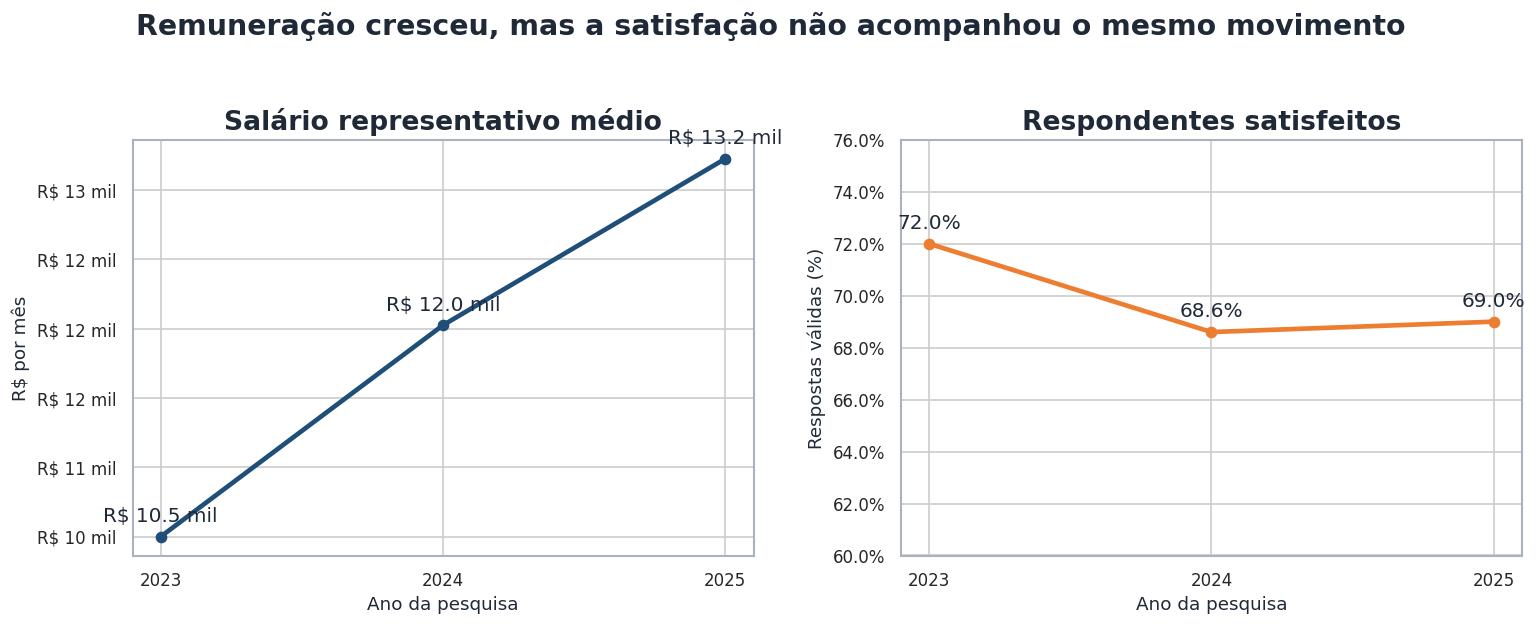

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/01_panorama_salario_satisfacao.png


In [12]:
# Ordena os indicadores para preservar a sequência temporal
panorama = df_indicadores.sort_values("ano_pesquisa").copy()

# Constrói dois painéis com escalas independentes e unidades explícitas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Exibe a evolução do salário representativo médio
axes[0].plot(
    panorama["ano_pesquisa"],
    panorama["salario_representativo_medio"],
    color=CORES["azul"], marker="o", linewidth=2.8
)
axes[0].set_title("Salário representativo médio")
axes[0].set_xlabel("Ano da pesquisa")
axes[0].set_ylabel("R$ por mês")
axes[0].set_xticks([2023, 2024, 2025])
axes[0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil")
)
for _, linha in panorama.iterrows():
    axes[0].annotate(
        f"R$ {linha['salario_representativo_medio']/1000:.1f} mil",
        (linha["ano_pesquisa"], linha["salario_representativo_medio"]),
        xytext=(0, 9), textcoords="offset points", ha="center"
    )

# Exibe a evolução do percentual de satisfeitos
axes[1].plot(
    panorama["ano_pesquisa"],
    panorama["pct_satisfeitos"],
    color=CORES["laranja"], marker="o", linewidth=2.8
)
axes[1].set_title("Respondentes satisfeitos")
axes[1].set_xlabel("Ano da pesquisa")
axes[1].set_ylabel("Respostas válidas (%)")
axes[1].set_xticks([2023, 2024, 2025])
axes[1].set_ylim(60, 76)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for _, linha in panorama.iterrows():
    axes[1].annotate(
        f"{linha['pct_satisfeitos']:.1f}%",
        (linha["ano_pesquisa"], linha["pct_satisfeitos"]),
        xytext=(0, 9), textcoords="offset points", ha="center"
    )

fig.suptitle("Remuneração cresceu, mas a satisfação não acompanhou o mesmo movimento", y=1.04, fontsize=17, fontweight="bold")
salvar_grafico("01_panorama_salario_satisfacao.png")

## 7. Evolução das competências técnicas

Os percentuais consideram somente respostas válidas para cada tecnologia. SQL continua amplamente utilizado, enquanto Python e AWS apresentaram as maiores expansões.

,ano_pesquisa,tecnologia,adocao_pct,respostas_validas
0,2023,SQL,83.7,3772
1,2023,Python,74.9,3772
2,2023,AWS,30.6,3613
3,2023,Power BI,57.1,3772
4,2024,SQL,87.7,3587
5,2024,Python,81.8,3587
6,2024,AWS,44.1,3587
7,2024,Power BI,55.2,3617
8,2025,SQL,84.2,2095
9,2025,Python,92.0,2095


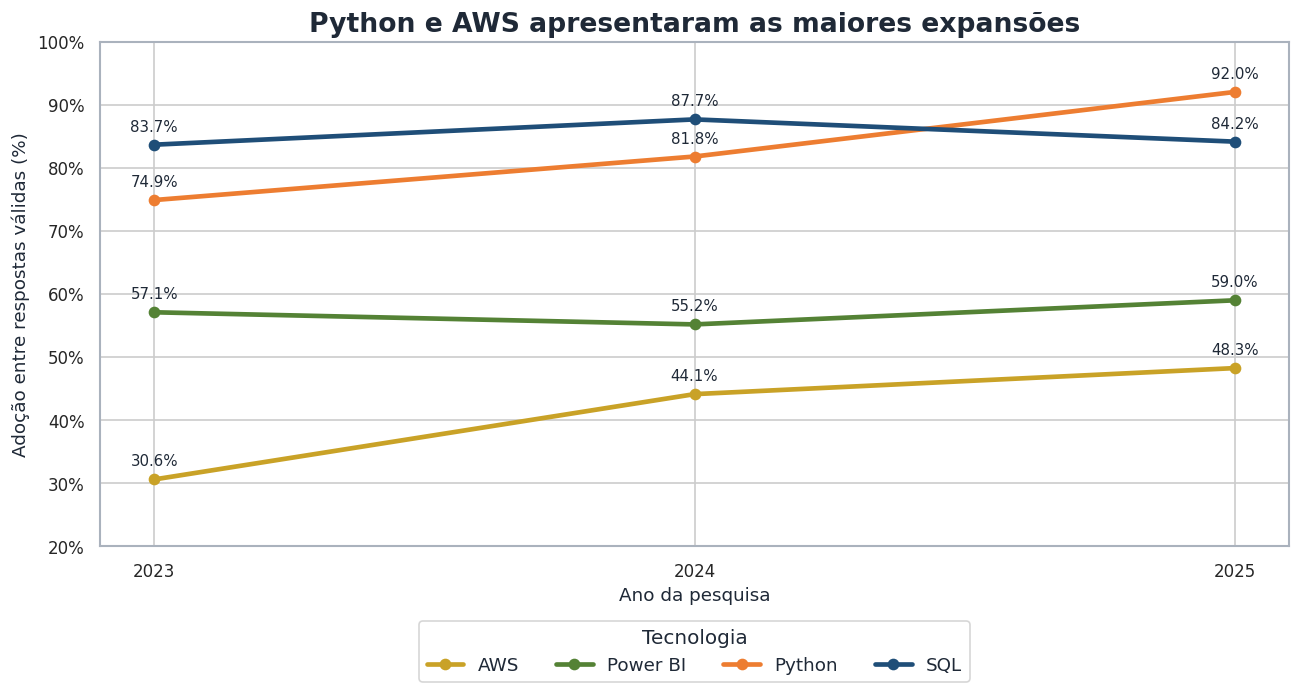

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/02_evolucao_tecnologias.png


In [13]:
# Calcula adoção e denominador válido para cada tecnologia e ano
tecnologias = ["usa_sql", "usa_python", "usa_aws", "usa_power_bi"]
rotulos_tecnologia = {
    "usa_sql": "SQL",
    "usa_python": "Python",
    "usa_aws": "AWS",
    "usa_power_bi": "Power BI",
}

adocao_tecnologias = []
for ano, grupo in df_tecnologias.groupby("ano_pesquisa"):
    for coluna in tecnologias:
        adocao_tecnologias.append({
            "ano_pesquisa": int(ano),
            "tecnologia": rotulos_tecnologia[coluna],
            "adocao_pct": 100 * grupo[coluna].mean(),
            "respostas_validas": int(grupo[coluna].notna().sum()),
        })

adocao_tecnologias = pd.DataFrame(adocao_tecnologias)

# Exibe a tabela que sustenta o gráfico
display(adocao_tecnologias.round({"adocao_pct": 1}))

# Desenha uma linha para cada tecnologia com cores estáveis
cores_tecnologia = {
    "SQL": CORES["azul"],
    "Python": CORES["laranja"],
    "AWS": CORES["dourado"],
    "Power BI": CORES["verde"],
}

fig, ax = plt.subplots(figsize=(11, 6))
for tecnologia, grupo in adocao_tecnologias.groupby("tecnologia"):
    grupo = grupo.sort_values("ano_pesquisa")
    ax.plot(
        grupo["ano_pesquisa"], grupo["adocao_pct"],
        label=tecnologia, color=cores_tecnologia[tecnologia],
        marker="o", linewidth=2.8
    )
    for _, linha in grupo.iterrows():
        ax.annotate(
            f"{linha['adocao_pct']:.1f}%",
            (linha["ano_pesquisa"], linha["adocao_pct"]),
            xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9
        )

ax.set_title("Python e AWS apresentaram as maiores expansões")
ax.set_xlabel("Ano da pesquisa")
ax.set_ylabel("Adoção entre respostas válidas (%)")
ax.set_xticks([2023, 2024, 2025])
ax.set_ylim(20, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title="Tecnologia", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
salvar_grafico("02_evolucao_tecnologias.png")

## 8. Adoção de IA para produtividade

A variável comparável está disponível apenas em 2024 e 2025. Os percentuais usam como denominador quem respondeu à pergunta, portanto não representam toda a amostra anual.

,ano_pesquisa,adocao_pct,respostas_validas
1,2024,93.5,3617
2,2025,97.9,2105


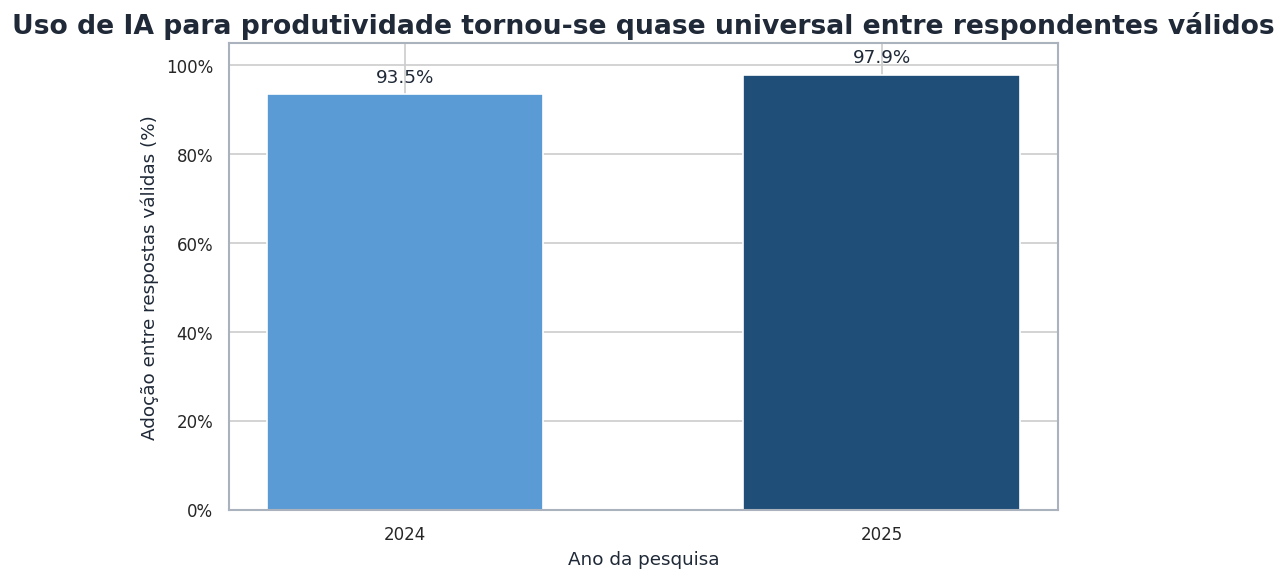

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/03_adocao_ia_produtividade.png


In [14]:
# Calcula adoção de IA e quantidade de respostas válidas por ano
adocao_ia = (
    df_ia.groupby("ano_pesquisa")
    .agg(
        adocao_pct=("usa_ia_produtividade", lambda serie: 100 * serie.mean()),
        respostas_validas=("usa_ia_produtividade", "count"),
    )
    .reset_index()
    .dropna(subset=["adocao_pct"])
    .sort_values("ano_pesquisa")
)

# Exibe os denominadores para evitar interpretação indevida
display(adocao_ia.round({"adocao_pct": 1}))

# Compara os dois anos disponíveis
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(
    adocao_ia["ano_pesquisa"].astype(str),
    adocao_ia["adocao_pct"],
    color=[CORES["azul_claro"], CORES["azul"]], width=0.58
)
ax.bar_label(barras, labels=[f"{v:.1f}%" for v in adocao_ia["adocao_pct"]], padding=5, fontsize=11)
ax.set_title("Uso de IA para produtividade tornou-se quase universal entre respondentes válidos")
ax.set_xlabel("Ano da pesquisa")
ax.set_ylabel("Adoção entre respostas válidas (%)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
salvar_grafico("03_adocao_ia_produtividade.png")

## 9. Remuneração por senioridade

A análise utiliza o salário representativo das faixas. A categoria Especialista/Staff aparece de maneira comparável apenas na edição de 2025 e, por isso, deve ser interpretada separadamente.

,ano_pesquisa,senioridade,salario_medio,profissionais
0,2023,Júnior,3911.48,1045
3,2024,Júnior,4157.26,868
7,2025,Júnior,4152.51,518
1,2023,Pleno,7539.15,1392
4,2024,Pleno,8049.42,1376
8,2025,Pleno,8298.71,775
2,2023,Sênior,13668.78,1419
5,2024,Sênior,14590.97,1572
9,2025,Sênior,14469.70,858
6,2025,Especialista/Staff+,20028.65,349


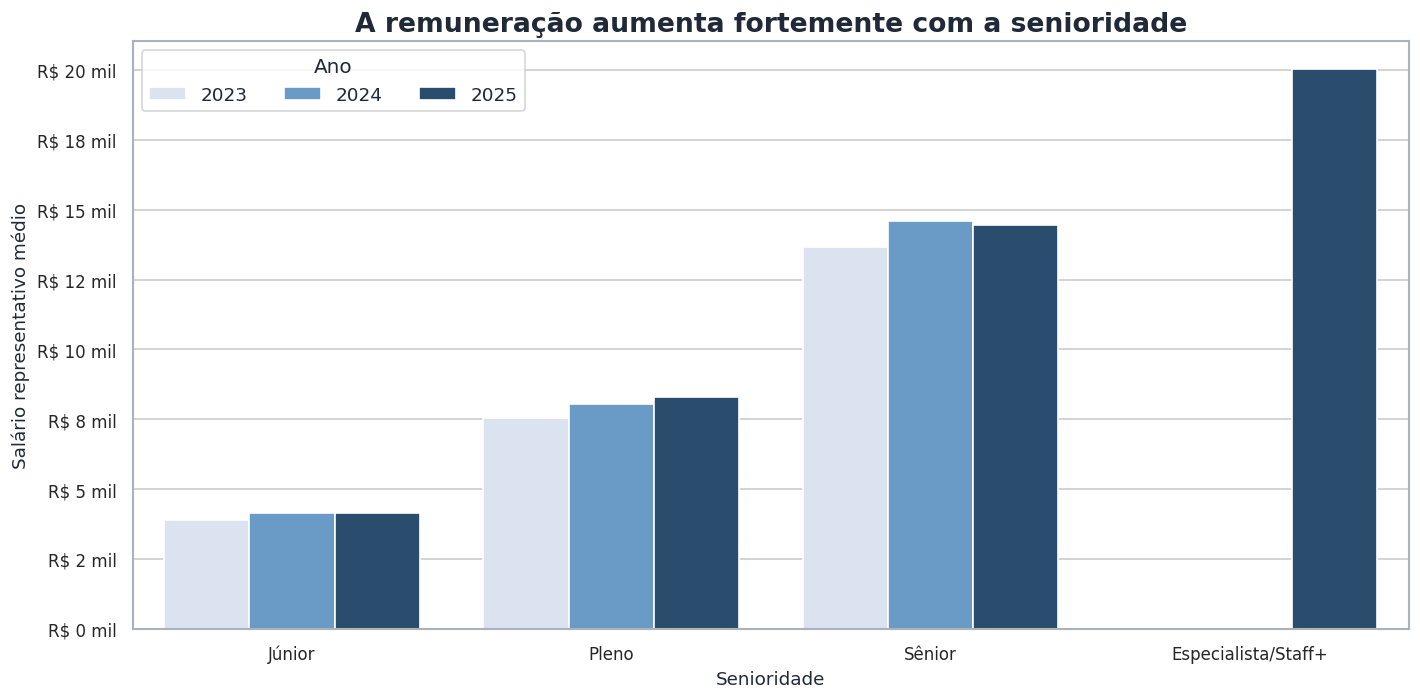

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/04_remuneracao_senioridade.png


In [15]:
# Mantém níveis de senioridade úteis para comparação
ordem_senioridade = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]
remuneracao_senioridade = (
    df_remuneracao[
        df_remuneracao["senioridade"].isin(ordem_senioridade)
        & df_remuneracao["salario_representativo"].notna()
    ]
    .groupby(["ano_pesquisa", "senioridade"])
    .agg(
        salario_medio=("salario_representativo", "mean"),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)

# Organiza a senioridade como categoria ordenada
remuneracao_senioridade["senioridade"] = pd.Categorical(
    remuneracao_senioridade["senioridade"],
    categories=ordem_senioridade,
    ordered=True,
)

# Exibe a tabela com médias e tamanhos de amostra
display(remuneracao_senioridade.sort_values(["senioridade", "ano_pesquisa"]).round(2))

# Desenha barras agrupadas por ano
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=remuneracao_senioridade,
    x="senioridade", y="salario_medio", hue="ano_pesquisa",
    palette=[CORES["cinza_claro"], CORES["azul_claro"], CORES["azul"]], ax=ax
)
ax.set_title("A remuneração aumenta fortemente com a senioridade")
ax.set_xlabel("Senioridade")
ax.set_ylabel("Salário representativo médio")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil"))
ax.legend(title="Ano", ncol=3, loc="upper left")
salvar_grafico("04_remuneracao_senioridade.png")

## 10. Modelo de trabalho

Para comparar a composição, o gráfico exclui “Não informado” e recalcula os percentuais sobre respostas válidas. A mudança mais recente aproxima a participação do remoto e do híbrido.

modelo_trabalho_resumo,Remoto,Híbrido,Presencial
ano_pesquisa,,,
2023,46.3,37.1,16.6
2024,45.7,38.0,16.3
2025,39.7,39.5,20.8


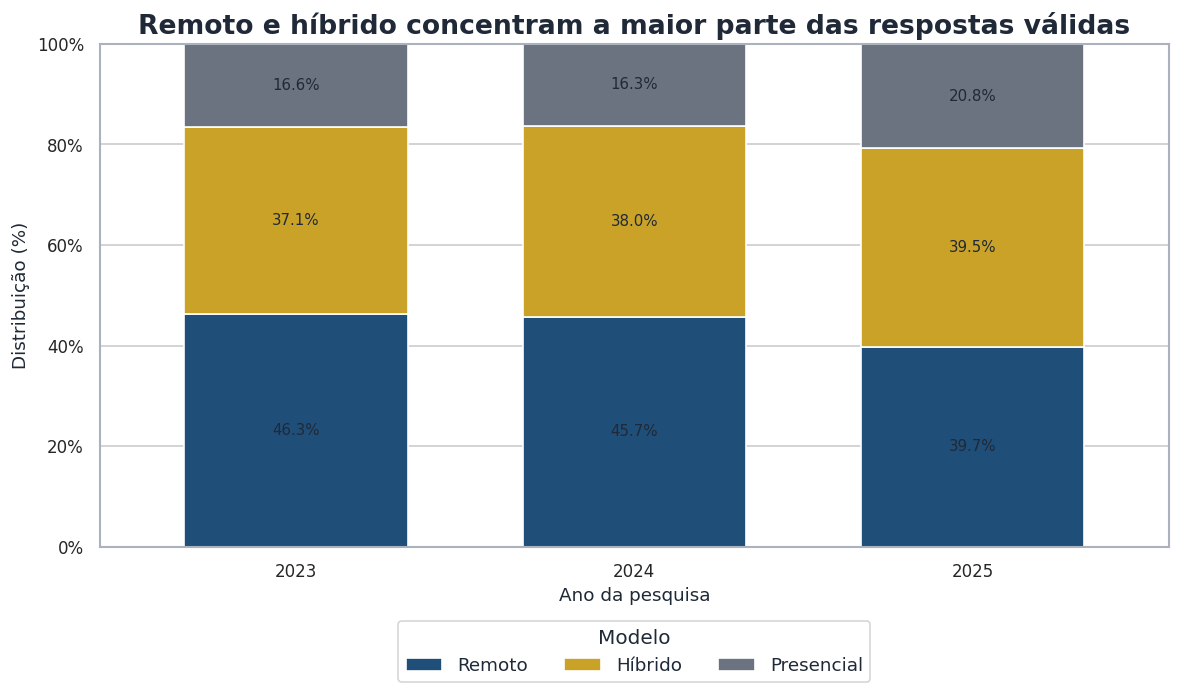

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/05_composicao_modelo_trabalho.png


In [16]:
# Mantém apenas os três modelos comparáveis
modelos_validos = ["Remoto", "Híbrido", "Presencial"]
trabalho_valido = df_modelo_trabalho[
    df_modelo_trabalho["modelo_trabalho_resumo"].isin(modelos_validos)
].copy()

# Calcula a participação dentro das respostas válidas de cada ano
composicao_trabalho = (
    trabalho_valido.groupby(["ano_pesquisa", "modelo_trabalho_resumo"])
    .size()
    .rename("profissionais")
    .reset_index()
)
composicao_trabalho["percentual"] = (
    100 * composicao_trabalho["profissionais"]
    / composicao_trabalho.groupby("ano_pesquisa")["profissionais"].transform("sum")
)

# Transforma os dados para um gráfico empilhado de composição
trabalho_pivot = (
    composicao_trabalho.pivot(
        index="ano_pesquisa", columns="modelo_trabalho_resumo", values="percentual"
    )
    .reindex(columns=modelos_validos)
    .sort_index()
)

# Exibe os percentuais usados no gráfico
display(trabalho_pivot.round(1))

# Cria barras 100% empilhadas
fig, ax = plt.subplots(figsize=(10, 6))
trabalho_pivot.plot(
    kind="bar", stacked=True, ax=ax,
    color=[CORES["azul"], CORES["dourado"], CORES["cinza"]], width=0.66
)
ax.set_title("Remoto e híbrido concentram a maior parte das respostas válidas")
ax.set_xlabel("Ano da pesquisa")
ax.set_ylabel("Distribuição (%)")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Modelo", ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.13))

# Inclui rótulos nas parcelas com espaço suficiente
acumulado = np.zeros(len(trabalho_pivot))
for coluna in trabalho_pivot.columns:
    valores = trabalho_pivot[coluna].values
    for indice, valor in enumerate(valores):
        ax.text(indice, acumulado[indice] + valor / 2, f"{valor:.1f}%", ha="center", va="center", fontsize=9)
    acumulado += valores

salvar_grafico("05_composicao_modelo_trabalho.png")

## 11. Satisfação, remuneração e modelo de trabalho

Respondentes satisfeitos apresentam salário representativo médio maior em todos os anos. Ao mesmo tempo, o remoto registra satisfação superior ao presencial. Os dados indicam associações simultâneas e não permitem atribuir a satisfação exclusivamente ao salário.

,ano_pesquisa,satisfeito,salario_medio,profissionais,grupo_satisfacao
0,2023,0.0,8000.38,1333,Insatisfeitos
1,2023,1.0,11474.26,3419,Satisfeitos
2,2024,0.0,9713.16,1527,Insatisfeitos
3,2024,1.0,13083.68,3334,Satisfeitos
4,2025,0.0,10484.52,1001,Insatisfeitos
5,2025,1.0,14458.45,2226,Satisfeitos


,ano_pesquisa,modelo_trabalho_resumo,satisfacao_pct,profissionais
0,2023,Híbrido,71.9,1762
1,2023,Presencial,54.7,790
2,2023,Remoto,78.2,2201
3,2024,Híbrido,68.9,1848
4,2024,Presencial,49.7,792
5,2024,Remoto,75.0,2221
6,2025,Híbrido,71.3,1276
7,2025,Presencial,54.0,670
8,2025,Remoto,74.5,1281


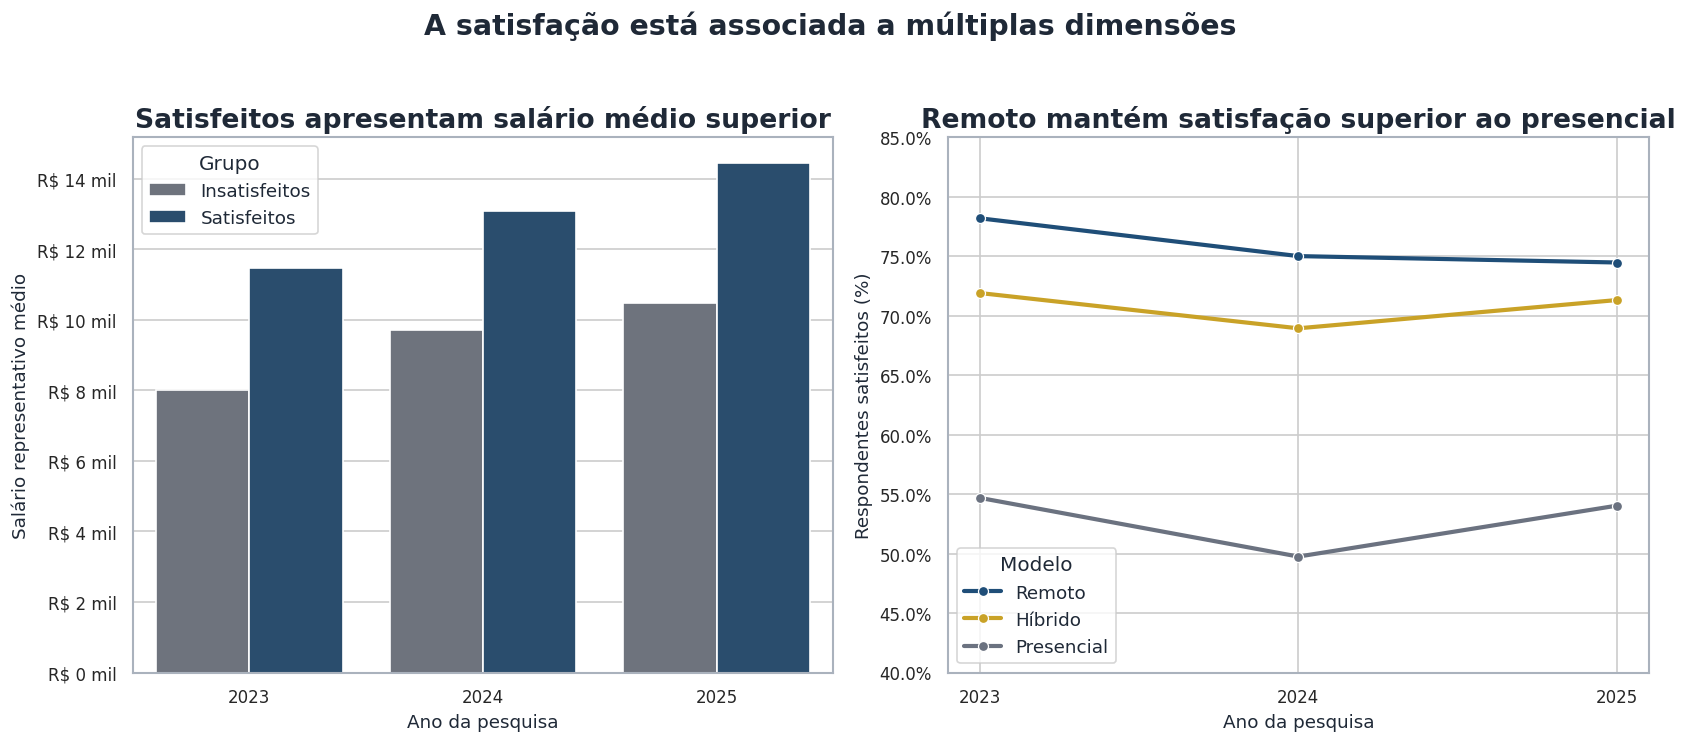

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/06_satisfacao_salario_modelo.png


In [17]:
# Compara o salário médio entre respondentes satisfeitos e insatisfeitos
satisfacao_salario = (
    df_satisfacao.dropna(subset=["satisfeito", "salario_representativo"])
    .groupby(["ano_pesquisa", "satisfeito"])
    .agg(
        salario_medio=("salario_representativo", "mean"),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)
satisfacao_salario["grupo_satisfacao"] = satisfacao_salario["satisfeito"].map({0: "Insatisfeitos", 1: "Satisfeitos"})

# Calcula satisfação por modelo de trabalho e ano
satisfacao_modelo = (
    df_satisfacao[
        df_satisfacao["satisfeito"].notna()
        & df_satisfacao["modelo_trabalho_resumo"].isin(modelos_validos)
    ]
    .groupby(["ano_pesquisa", "modelo_trabalho_resumo"])
    .agg(
        satisfacao_pct=("satisfeito", lambda serie: 100 * serie.mean()),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)

# Exibe as duas tabelas analíticas
display(satisfacao_salario.round(2))
display(satisfacao_modelo.round(1))

# Cria dois painéis complementares
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Painel 1: salário médio por satisfação
sns.barplot(
    data=satisfacao_salario,
    x="ano_pesquisa", y="salario_medio", hue="grupo_satisfacao",
    palette=[CORES["cinza"], CORES["azul"]], ax=axes[0]
)
axes[0].set_title("Satisfeitos apresentam salário médio superior")
axes[0].set_xlabel("Ano da pesquisa")
axes[0].set_ylabel("Salário representativo médio")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil"))
axes[0].legend(title="Grupo")

# Painel 2: satisfação por modelo de trabalho
sns.lineplot(
    data=satisfacao_modelo,
    x="ano_pesquisa", y="satisfacao_pct", hue="modelo_trabalho_resumo",
    hue_order=modelos_validos,
    palette=[CORES["azul"], CORES["dourado"], CORES["cinza"]],
    marker="o", linewidth=2.5, ax=axes[1]
)
axes[1].set_title("Remoto mantém satisfação superior ao presencial")
axes[1].set_xlabel("Ano da pesquisa")
axes[1].set_ylabel("Respondentes satisfeitos (%)")
axes[1].set_xticks([2023, 2024, 2025])
axes[1].set_ylim(40, 85)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(title="Modelo")

fig.suptitle("A satisfação está associada a múltiplas dimensões", y=1.03, fontsize=17, fontweight="bold")
salvar_grafico("06_satisfacao_salario_modelo.png")

## 12. Diversidade e remuneração controlada por senioridade

A diferença agregada entre homens e mulheres pode refletir composição de cargos, senioridade, experiência e região. O recorte abaixo compara as médias dentro dos mesmos níveis, reduzindo parte desse efeito de composição sem constituir uma análise causal completa.

genero,ano_pesquisa,senioridade,Feminino,Masculino,diferenca_feminino_vs_masculino_pct
0,2023,Júnior,3693.98,3994.61,-7.53
1,2023,Pleno,7462.91,7572.11,-1.44
2,2023,Sênior,12420.20,13957.50,-11.01
3,2024,Júnior,4148.76,4101.93,1.14
4,2024,Pleno,7824.66,8133.20,-3.79
5,2024,Sênior,12543.28,15155.94,-17.24
6,2025,Júnior,3780.82,4322.89,-12.54
7,2025,Pleno,8335.26,8296.33,0.47
8,2025,Sênior,12165.73,15077.78,-19.31


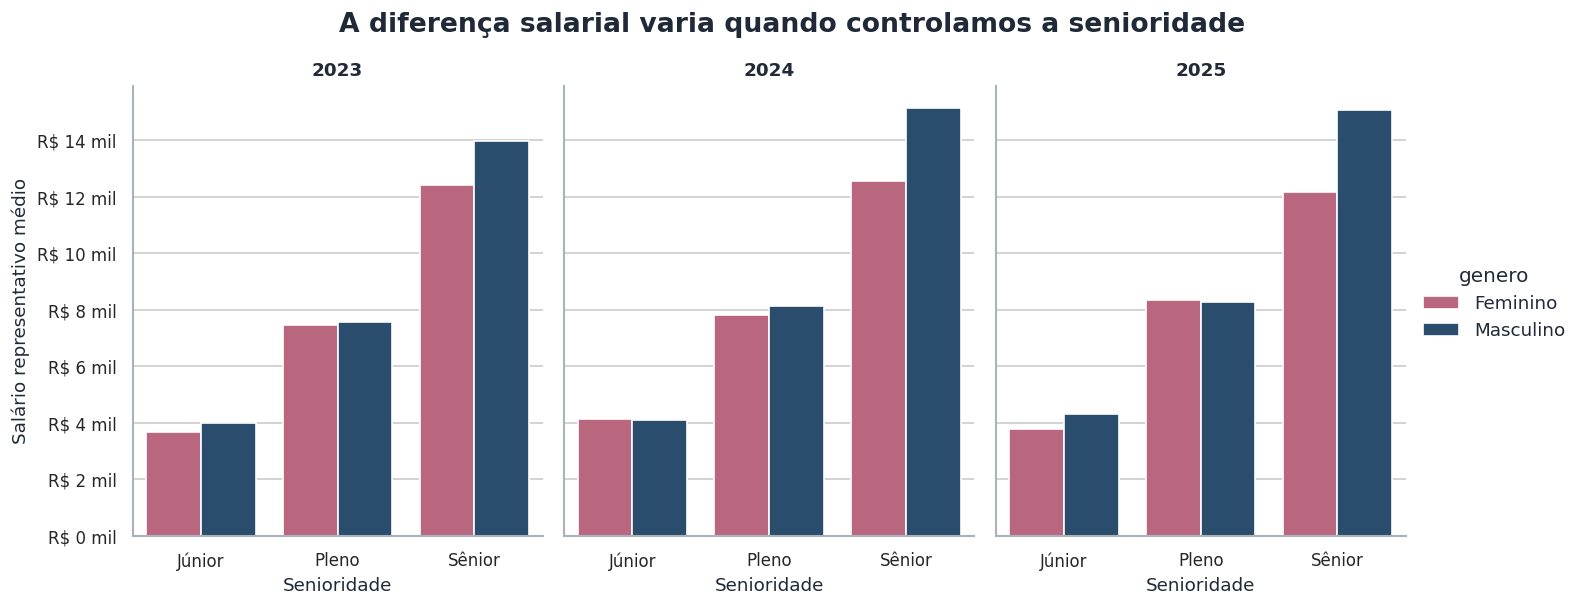

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/07_remuneracao_genero_senioridade.png


In [18]:
# Mantém os dois grupos com amostras suficientes e senioridades comparáveis
niveis_comparaveis = ["Júnior", "Pleno", "Sênior"]
genero_senioridade = df_remuneracao[
    df_remuneracao["genero"].isin(["Feminino", "Masculino"])
    & df_remuneracao["senioridade"].isin(niveis_comparaveis)
    & df_remuneracao["salario_representativo"].notna()
].copy()

# Calcula salário médio e tamanho da amostra por grupo
remuneracao_genero = (
    genero_senioridade.groupby(["ano_pesquisa", "senioridade", "genero"])
    .agg(
        salario_medio=("salario_representativo", "mean"),
        profissionais=("id_respondente", "count"),
    )
    .reset_index()
)

# Calcula a diferença percentual feminina em relação à média masculina dentro do mesmo nível
comparacao_genero = (
    remuneracao_genero.pivot_table(
        index=["ano_pesquisa", "senioridade"], columns="genero", values="salario_medio"
    )
    .reset_index()
)
comparacao_genero["diferenca_feminino_vs_masculino_pct"] = (
    100 * (comparacao_genero["Feminino"] / comparacao_genero["Masculino"] - 1)
)

# Exibe o recorte ajustado por senioridade
display(comparacao_genero.round(2))

# Ordena os níveis no gráfico
remuneracao_genero["senioridade"] = pd.Categorical(
    remuneracao_genero["senioridade"], categories=niveis_comparaveis, ordered=True
)

# Cria pequenos múltiplos, um para cada ano
grafico_genero = sns.catplot(
    data=remuneracao_genero,
    x="senioridade", y="salario_medio", hue="genero", col="ano_pesquisa",
    kind="bar", height=4.8, aspect=0.82,
    palette={"Feminino": CORES["rosa"], "Masculino": CORES["azul"]}
)
grafico_genero.set_axis_labels("Senioridade", "Salário representativo médio")
grafico_genero.set_titles("{col_name}")
grafico_genero.figure.suptitle("A diferença salarial varia quando controlamos a senioridade", y=1.05, fontsize=16, fontweight="bold")
for eixo in grafico_genero.axes.flat:
    eixo.yaxis.set_major_formatter(mtick.FuncFormatter(lambda valor, _: f"R$ {valor/1000:.0f} mil"))
    eixo.tick_params(axis="x", rotation=0)

plt.savefig(OUTPUT_DIR / "07_remuneracao_genero_senioridade.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("Gráfico salvo em:", OUTPUT_DIR / "07_remuneracao_genero_senioridade.png")

## 13. Principais cargos

Como os volumes anuais são diferentes, utilizamos participação percentual entre respondentes com cargo informado, e não apenas contagens absolutas.

,ano_pesquisa,cargo_resumido,profissionais,participacao_pct
1,2023,Analista de Dados,907,23.5
6,2023,Cientista de Dados,687,17.8
11,2023,Engenharia/Arquitetura de Dados,684,17.7
0,2023,Analista de BI,506,13.1
14,2023,Outros cargos,262,6.8
18,2024,Analista de Dados,957,25.1
23,2024,Cientista de Dados,687,18.0
26,2024,Engenharia/Arquitetura de Dados,612,16.0
17,2024,Analista de BI,396,10.4
29,2024,Outros cargos,254,6.7


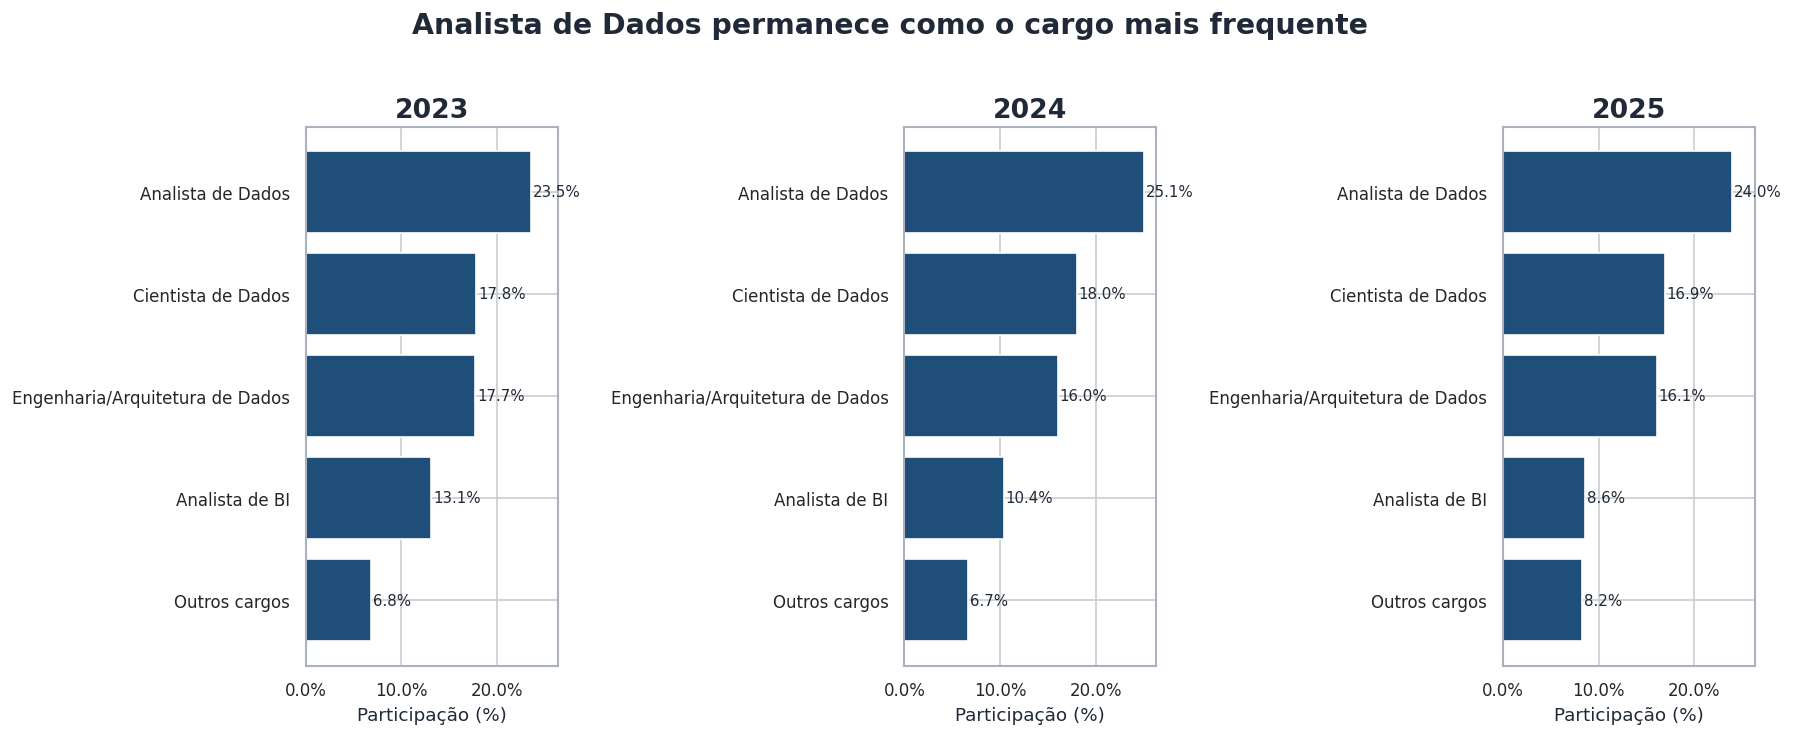

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/08_top_cargos.png


In [19]:
# Calcula a participação de cada cargo dentro dos cargos informados em cada ano
cargos = (
    df_mercado.dropna(subset=["cargo"])
    .groupby(["ano_pesquisa", "cargo"])
    .size()
    .rename("profissionais")
    .reset_index()
)
cargos["participacao_pct"] = (
    100 * cargos["profissionais"]
    / cargos.groupby("ano_pesquisa")["profissionais"].transform("sum")
)

# Seleciona os cinco cargos mais frequentes de cada ano
top_cargos = (
    cargos.sort_values(["ano_pesquisa", "profissionais"], ascending=[True, False])
    .groupby("ano_pesquisa", group_keys=False)
    .head(5)
)

# Simplifica rótulos longos sem alterar a categoria original nos dados
nomes_cargos = {
    "Analista de Dados/Data Analyst": "Analista de Dados",
    "Cientista de Dados/Data Scientist": "Cientista de Dados",
    "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect": "Engenharia/Arquitetura de Dados",
    "Engenheiro de Dados/Data Engineer/Data Architect": "Engenharia/Arquitetura de Dados",
    "Analista de BI/BI Analyst": "Analista de BI",
    "Outra Opção": "Outros cargos",
}
top_cargos["cargo_resumido"] = top_cargos["cargo"].replace(nomes_cargos)

# Exibe as participações exatas antes do gráfico
display(top_cargos[["ano_pesquisa", "cargo_resumido", "profissionais", "participacao_pct"]].round(1))

# Cria um painel por ano com escala comum
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True)
for eixo, (ano, grupo) in zip(axes, top_cargos.groupby("ano_pesquisa")):
    grupo = grupo.sort_values("participacao_pct", ascending=True)
    eixo.barh(grupo["cargo_resumido"], grupo["participacao_pct"], color=CORES["azul"])
    eixo.set_title(str(ano))
    eixo.set_xlabel("Participação (%)")
    eixo.xaxis.set_major_formatter(mtick.PercentFormatter())
    for indice, valor in enumerate(grupo["participacao_pct"]):
        eixo.text(valor + 0.2, indice, f"{valor:.1f}%", va="center", fontsize=9)

fig.suptitle("Analista de Dados permanece como o cargo mais frequente", y=1.02, fontsize=17, fontweight="bold")
salvar_grafico("08_top_cargos.png")

# 14. Análise estratégica para uma Instituição Financeira

Esta seção reposiciona a análise para o problema de negócio do Tech Challenge: apoiar uma Instituição Financeira de grande porte na expansão de sua área de Dados, Analytics e Inteligência Artificial.

As comparações utilizam o setor **Finanças ou Bancos** e o confrontam com o mercado geral. Todos os percentuais são calculados sobre respostas válidas de cada indicador. Os resultados descrevem a amostra e não devem ser interpretados como relações causais ou como um censo do mercado brasileiro.


In [20]:
# Define o recorte setorial e funções auxiliares para percentuais válidos
SETOR_FINANCEIRO = "Finanças ou Bancos"
ANO_REFERENCIA = 2025

def percentual_valido(serie):
    valores = serie.dropna()
    return 100 * valores.mean() if len(valores) else np.nan

def adicionar_rotulos_barras(ax, formato="{:.1f}%", deslocamento=0.4):
    for container in ax.containers:
        rotulos = []
        for barra in container:
            valor = barra.get_height() if barra.get_height() != 0 else barra.get_width()
            rotulos.append(formato.format(valor))
        try:
            ax.bar_label(container, labels=rotulos, padding=3, fontsize=9)
        except ValueError:
            pass

print("Setor analisado:", SETOR_FINANCEIRO)
print("Ano principal de comparação:", ANO_REFERENCIA)


Setor analisado: Finanças ou Bancos
Ano principal de comparação: 2025


## 14.1 Participação dos principais setores

Finanças ou Bancos aparece como o maior setor individual entre respondentes com setor informado nos três anos. Isso indica que a instituição disputará profissionais em um mercado que já possui forte presença de bancos, fintechs e empresas de tecnologia.


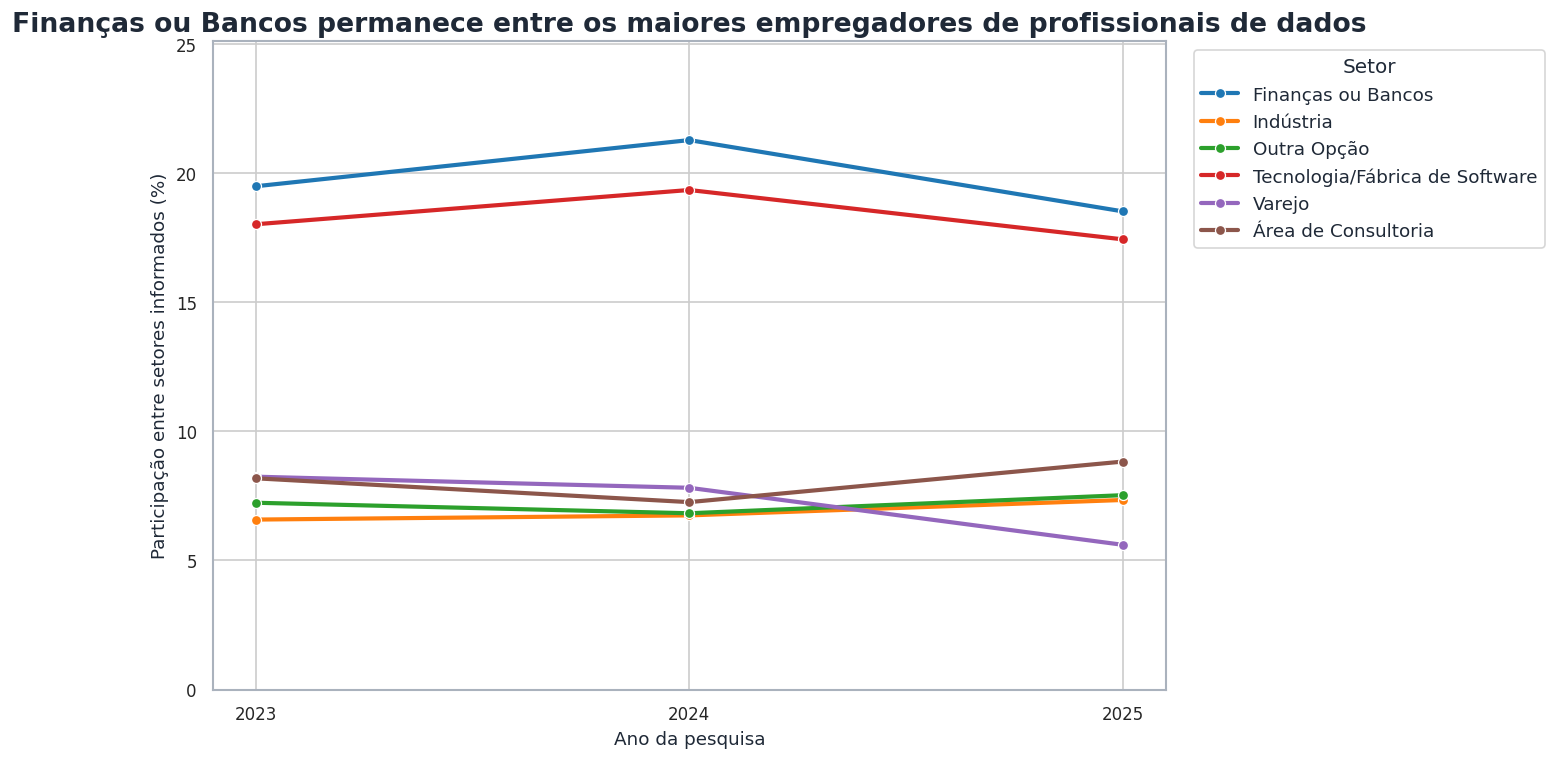

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/09_participacao_principais_setores.png


,ano_pesquisa,setor,profissionais,participacao_pct
4,2023,Finanças ou Bancos,927,19.503471
25,2024,Finanças ou Bancos,1035,21.291915
46,2025,Finanças ou Bancos,598,18.531143


In [21]:
# Calcula a participação anual dos setores sobre respostas com setor informado
participacao_setores = (
    df_mercado.dropna(subset=["setor"])
    .groupby(["ano_pesquisa", "setor"])
    .size()
    .rename("profissionais")
    .reset_index()
)
participacao_setores["participacao_pct"] = (
    100 * participacao_setores["profissionais"] /
    participacao_setores.groupby("ano_pesquisa")["profissionais"].transform("sum")
)

top_setores = (
    participacao_setores.groupby("setor")["profissionais"]
    .sum().nlargest(6).index
)
setores_plot = participacao_setores[participacao_setores["setor"].isin(top_setores)].copy()

plt.figure(figsize=(12, 6.5))
sns.lineplot(
    data=setores_plot, x="ano_pesquisa", y="participacao_pct", hue="setor",
    marker="o", linewidth=2.5, palette="tab10"
)
plt.title("Finanças ou Bancos permanece entre os maiores empregadores de profissionais de dados")
plt.xlabel("Ano da pesquisa")
plt.ylabel("Participação entre setores informados (%)")
plt.xticks([2023, 2024, 2025])
plt.legend(title="Setor", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, max(setores_plot["participacao_pct"]) * 1.18)
salvar_grafico("09_participacao_principais_setores.png")

display(
    participacao_setores[participacao_setores["setor"].eq(SETOR_FINANCEIRO)]
    .sort_values("ano_pesquisa")
)


## 14.2 Composição de cargos no setor financeiro

O setor combina análise, ciência, engenharia e tradução de negócio. A evidência não sustenta uma expansão concentrada somente em BI ou somente em Ciência de Dados.


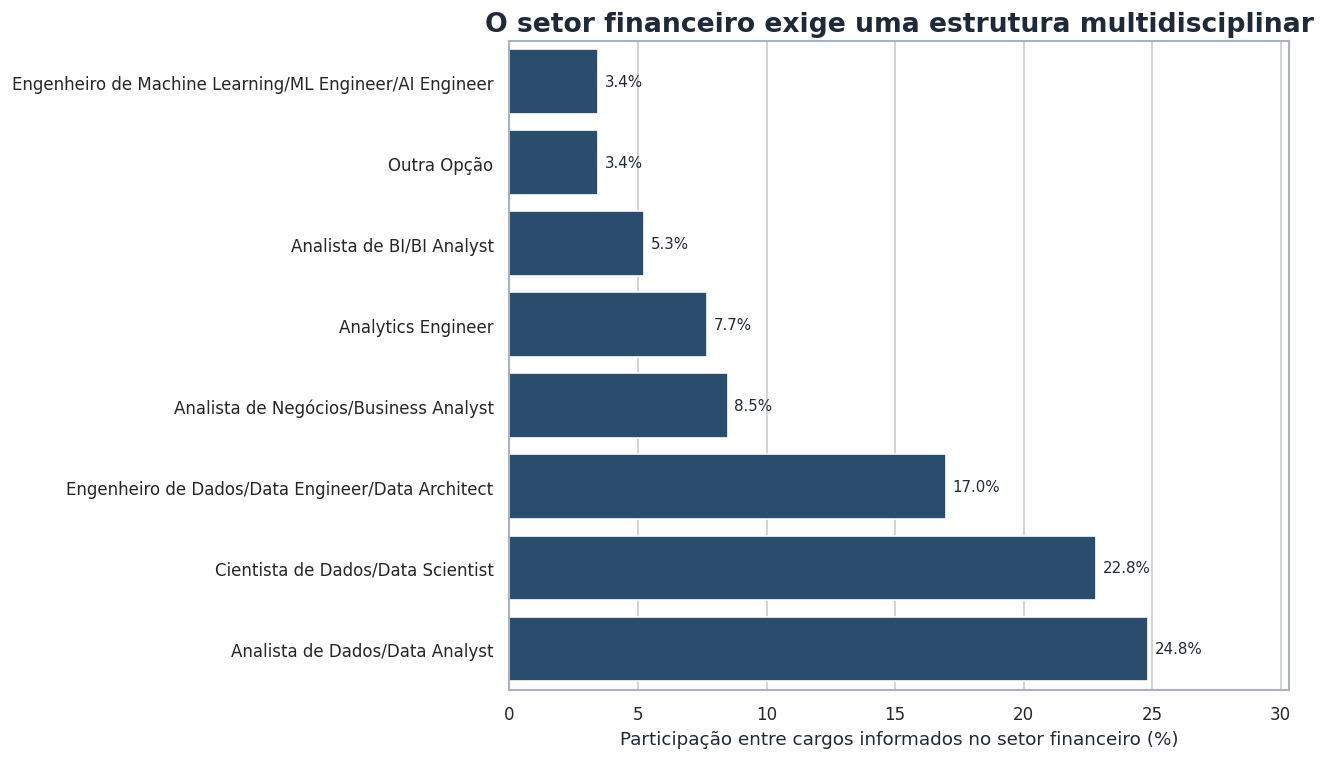

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/10_composicao_cargos_setor_financeiro.png


,cargo,profissionais,participacao_pct
0,Analista de Dados/Data Analyst,123,24.848485
1,Cientista de Dados/Data Scientist,113,22.828283
2,Engenheiro de Dados/Data Engineer/Data Architect,84,16.969697
3,Analista de Negócios/Business Analyst,42,8.484848
4,Analytics Engineer,38,7.676768
5,Analista de BI/BI Analyst,26,5.252525
6,Engenheiro de Machine Learning/ML Engineer/AI ...,17,3.434343
7,Outra Opção,17,3.434343


In [22]:
# Calcula a composição dos cargos informados no setor financeiro em 2025
cargos_financeiro = (
    df_mercado[
        (df_mercado["ano_pesquisa"].eq(ANO_REFERENCIA)) &
        (df_mercado["setor"].eq(SETOR_FINANCEIRO))
    ]
    .dropna(subset=["cargo"])["cargo"]
    .value_counts()
    .rename_axis("cargo")
    .reset_index(name="profissionais")
)
cargos_financeiro["participacao_pct"] = 100 * cargos_financeiro["profissionais"] / cargos_financeiro["profissionais"].sum()
cargos_financeiro = cargos_financeiro.head(8).sort_values("participacao_pct")

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(data=cargos_financeiro, x="participacao_pct", y="cargo", color=CORES["azul"])
plt.title("O setor financeiro exige uma estrutura multidisciplinar")
plt.xlabel("Participação entre cargos informados no setor financeiro (%)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=9)
plt.xlim(0, cargos_financeiro["participacao_pct"].max() * 1.22)
salvar_grafico("10_composicao_cargos_setor_financeiro.png")

display(cargos_financeiro.sort_values("participacao_pct", ascending=False))


## 14.3 Senioridade: financeiro versus mercado

Sêniores e Especialistas/Staff+ representam mais da metade dos profissionais do setor financeiro em 2025. Para expandir com sustentabilidade, a instituição deverá combinar contratação seletiva de experiência crítica com formação interna de júniores e plenos.


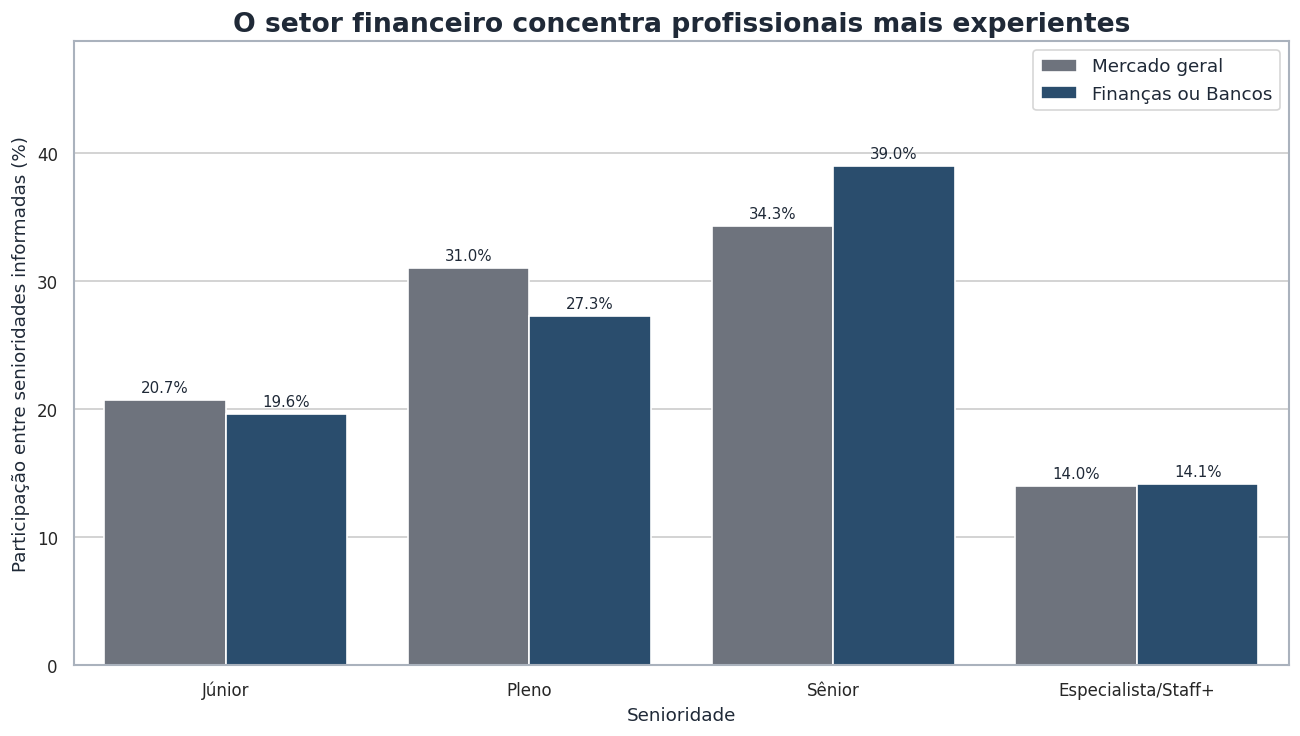

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/11_senioridade_financeiro_vs_mercado.png


,senioridade,Mercado geral,Finanças ou Bancos
0,Júnior,20.7,19.6
1,Pleno,31.0,27.3
2,Sênior,34.3,39.0
3,Especialista/Staff+,14.0,14.1


In [23]:
# Compara a composição de senioridade em 2025
ordem_senioridade_fin = ["Júnior", "Pleno", "Sênior", "Especialista/Staff+"]
base_senioridade = df_mercado[
    df_mercado["ano_pesquisa"].eq(ANO_REFERENCIA) &
    df_mercado["senioridade"].isin(ordem_senioridade_fin)
].copy()
base_senioridade["grupo"] = np.where(
    base_senioridade["setor"].eq(SETOR_FINANCEIRO), "Finanças ou Bancos", "Mercado geral"
)

# O mercado geral inclui todos os respondentes, inclusive o setor financeiro.
mercado_sen = (
    df_mercado[df_mercado["ano_pesquisa"].eq(ANO_REFERENCIA)]
    .dropna(subset=["senioridade"])["senioridade"].value_counts(normalize=True).mul(100)
)
financeiro_sen = (
    df_mercado[(df_mercado["ano_pesquisa"].eq(ANO_REFERENCIA)) & (df_mercado["setor"].eq(SETOR_FINANCEIRO))]
    .dropna(subset=["senioridade"])["senioridade"].value_counts(normalize=True).mul(100)
)
senioridade_comparacao = pd.DataFrame({"Mercado geral": mercado_sen, "Finanças ou Bancos": financeiro_sen})
senioridade_comparacao = senioridade_comparacao.reindex(ordem_senioridade_fin).fillna(0).reset_index(names="senioridade")
senioridade_long = senioridade_comparacao.melt("senioridade", var_name="grupo", value_name="participacao_pct")

plt.figure(figsize=(11, 6.3))
ax = sns.barplot(
    data=senioridade_long, x="senioridade", y="participacao_pct", hue="grupo",
    palette={"Mercado geral": CORES["cinza"], "Finanças ou Bancos": CORES["azul"]}
)
plt.title("O setor financeiro concentra profissionais mais experientes")
plt.xlabel("Senioridade")
plt.ylabel("Participação entre senioridades informadas (%)")
plt.legend(title="")
adicionar_rotulos_barras(ax)
plt.ylim(0, senioridade_long["participacao_pct"].max() * 1.25)
salvar_grafico("11_senioridade_financeiro_vs_mercado.png")

display(senioridade_comparacao.round(1))


## 14.4 Tecnologias: financeiro versus mercado

SQL permanece como fundamento, Python tornou-se praticamente universal e AWS apresenta adoção substancialmente superior no setor financeiro. O indicador de IA mede uso para produtividade, e não implantação de modelos em produção.


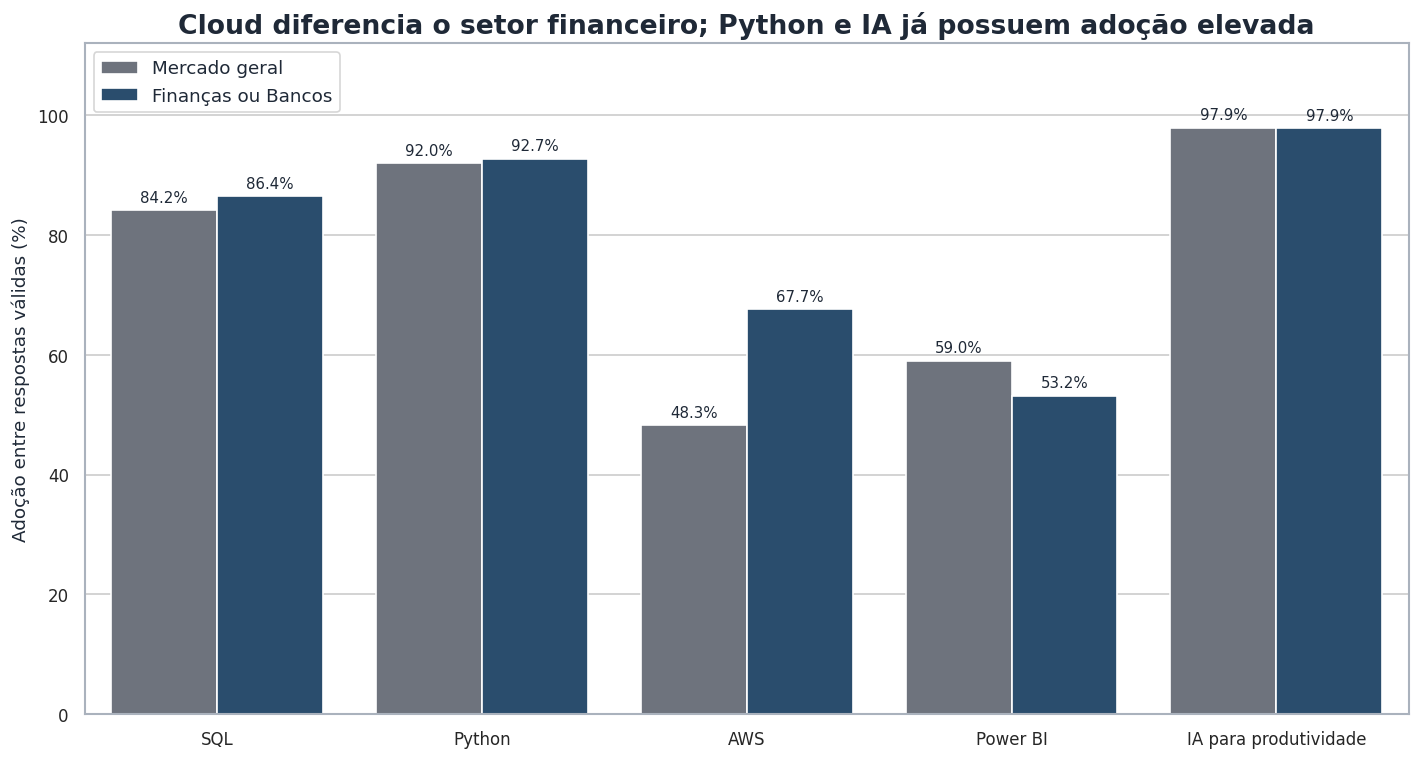

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/12_tecnologias_financeiro_vs_mercado.png


,grupo,tecnologia,adocao_pct,respostas_validas
0,Mercado geral,SQL,84.2,2095
1,Mercado geral,Python,92.0,2095
2,Mercado geral,AWS,48.3,2095
3,Mercado geral,Power BI,59.0,2105
4,Finanças ou Bancos,SQL,86.4,427
5,Finanças ou Bancos,Python,92.7,427
6,Finanças ou Bancos,AWS,67.7,427
7,Finanças ou Bancos,Power BI,53.2,427
8,Mercado geral,IA para produtividade,97.9,2105
9,Finanças ou Bancos,IA para produtividade,97.9,427


In [24]:
# Compara adoção tecnológica em 2025 usando denominadores válidos por indicador
mapa_tecnologias = {
    "SQL": "usa_sql", "Python": "usa_python", "AWS": "usa_aws", "Power BI": "usa_power_bi"
}
linhas_tecnologia = []
for grupo, filtro in {
    "Mercado geral": df_tecnologias["ano_pesquisa"].eq(ANO_REFERENCIA),
    "Finanças ou Bancos": df_tecnologias["ano_pesquisa"].eq(ANO_REFERENCIA) & df_tecnologias["setor"].eq(SETOR_FINANCEIRO),
}.items():
    base = df_tecnologias[filtro]
    for tecnologia, coluna in mapa_tecnologias.items():
        linhas_tecnologia.append({
            "grupo": grupo, "tecnologia": tecnologia,
            "adocao_pct": percentual_valido(base[coluna]),
            "respostas_validas": int(base[coluna].notna().sum()),
        })

# IA vem da tabela Gold específica e possui denominador próprio.
for grupo, filtro in {
    "Mercado geral": df_ia["ano_pesquisa"].eq(ANO_REFERENCIA),
    "Finanças ou Bancos": df_ia["ano_pesquisa"].eq(ANO_REFERENCIA) & df_ia["setor"].eq(SETOR_FINANCEIRO),
}.items():
    base = df_ia[filtro]
    linhas_tecnologia.append({
        "grupo": grupo, "tecnologia": "IA para produtividade",
        "adocao_pct": percentual_valido(base["usa_ia_produtividade"]),
        "respostas_validas": int(base["usa_ia_produtividade"].notna().sum()),
    })

tecnologia_comparacao = pd.DataFrame(linhas_tecnologia)
ordem_tecnologias = ["SQL", "Python", "AWS", "Power BI", "IA para produtividade"]

plt.figure(figsize=(12, 6.5))
ax = sns.barplot(
    data=tecnologia_comparacao, x="tecnologia", y="adocao_pct", hue="grupo",
    order=ordem_tecnologias,
    palette={"Mercado geral": CORES["cinza"], "Finanças ou Bancos": CORES["azul"]}
)
plt.title("Cloud diferencia o setor financeiro; Python e IA já possuem adoção elevada")
plt.xlabel("")
plt.ylabel("Adoção entre respostas válidas (%)")
plt.legend(title="")
adicionar_rotulos_barras(ax)
plt.ylim(0, 112)
salvar_grafico("12_tecnologias_financeiro_vs_mercado.png")

display(tecnologia_comparacao.round(1))


## 14.5 Remuneração por senioridade: financeiro versus mercado

O setor financeiro apresenta remuneração representativa superior em 2025, sobretudo no nível júnior. O indicador é uma aproximação baseada no ponto médio das faixas salariais declaradas.


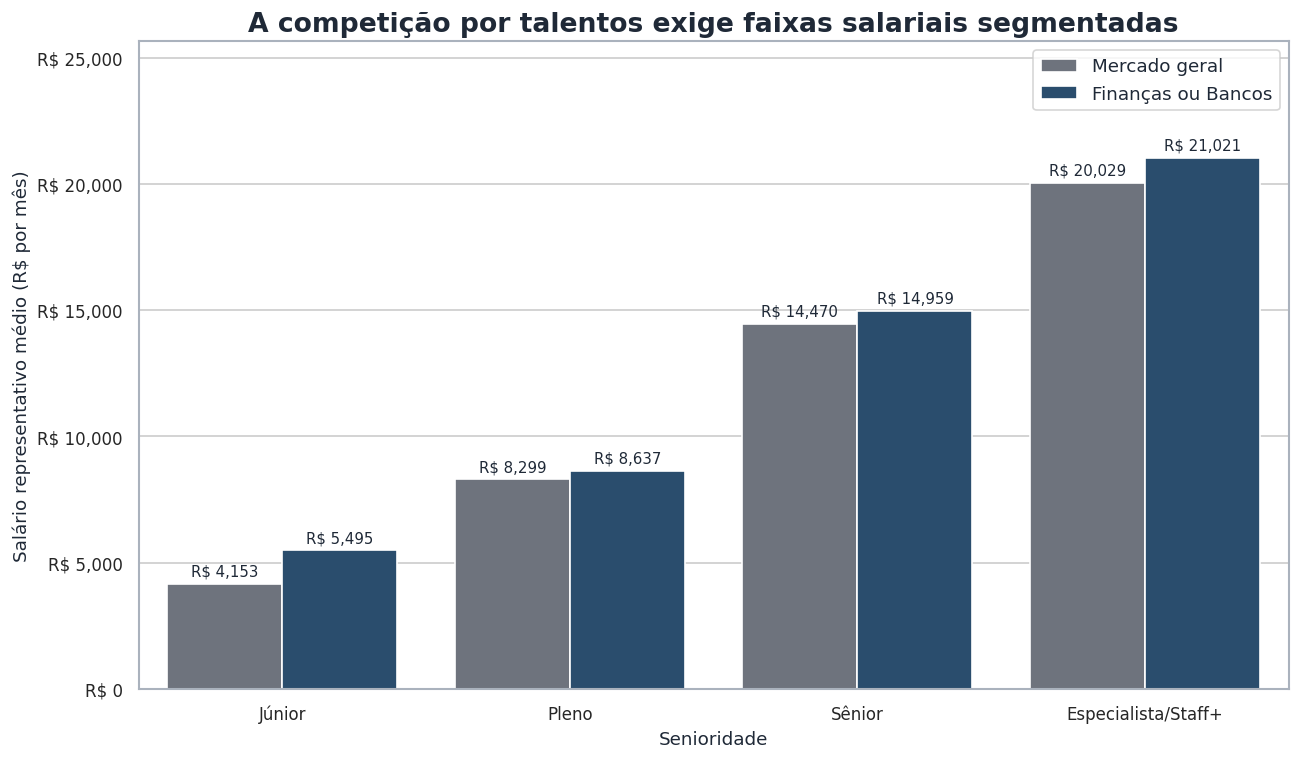

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/13_remuneracao_financeiro_vs_mercado.png


,senioridade,Mercado geral,Finanças ou Bancos,n_mercado,n_financeiro,premio_financeiro_pct
0,Júnior,4152.5,5494.8,518,97,32.3
1,Pleno,8298.7,8637.0,775,135,4.1
2,Sênior,14469.7,14958.5,858,193,3.4
3,Especialista/Staff+,20028.7,21021.4,349,70,5.0


In [25]:
# Compara remuneração representativa média por senioridade em 2025
base_rem_2025 = df_remuneracao[
    df_remuneracao["ano_pesquisa"].eq(ANO_REFERENCIA) &
    df_remuneracao["senioridade"].isin(ordem_senioridade_fin)
].dropna(subset=["salario_representativo"]).copy()

mercado_rem = base_rem_2025.groupby("senioridade")["salario_representativo"].agg(["mean", "count"])
financeiro_rem = base_rem_2025[base_rem_2025["setor"].eq(SETOR_FINANCEIRO)].groupby("senioridade")["salario_representativo"].agg(["mean", "count"])
remuneracao_comparacao = pd.DataFrame({
    "Mercado geral": mercado_rem["mean"],
    "Finanças ou Bancos": financeiro_rem["mean"],
    "n_mercado": mercado_rem["count"],
    "n_financeiro": financeiro_rem["count"],
}).reindex(ordem_senioridade_fin).reset_index(names="senioridade")
remuneracao_comparacao["premio_financeiro_pct"] = 100 * (
    remuneracao_comparacao["Finanças ou Bancos"] / remuneracao_comparacao["Mercado geral"] - 1
)
rem_long = remuneracao_comparacao.melt(
    id_vars=["senioridade"], value_vars=["Mercado geral", "Finanças ou Bancos"],
    var_name="grupo", value_name="salario_medio"
)

plt.figure(figsize=(11, 6.5))
ax = sns.barplot(
    data=rem_long, x="senioridade", y="salario_medio", hue="grupo",
    palette={"Mercado geral": CORES["cinza"], "Finanças ou Bancos": CORES["azul"]}
)
plt.title("A competição por talentos exige faixas salariais segmentadas")
plt.xlabel("Senioridade")
plt.ylabel("Salário representativo médio (R$ por mês)")
plt.legend(title="")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
for container in ax.containers:
    ax.bar_label(container, labels=[f"R$ {v:,.0f}" for v in container.datavalues], padding=3, fontsize=9)
plt.ylim(0, rem_long["salario_medio"].max() * 1.22)
salvar_grafico("13_remuneracao_financeiro_vs_mercado.png")

display(remuneracao_comparacao.round(1))


## 14.6 Modelo de trabalho e satisfação no setor financeiro

Em 2025, o modelo híbrido já representa a maior parcela do setor financeiro. A satisfação observada no híbrido é praticamente igual à do remoto, tornando o híbrido flexível uma alternativa plausível para a instituição.


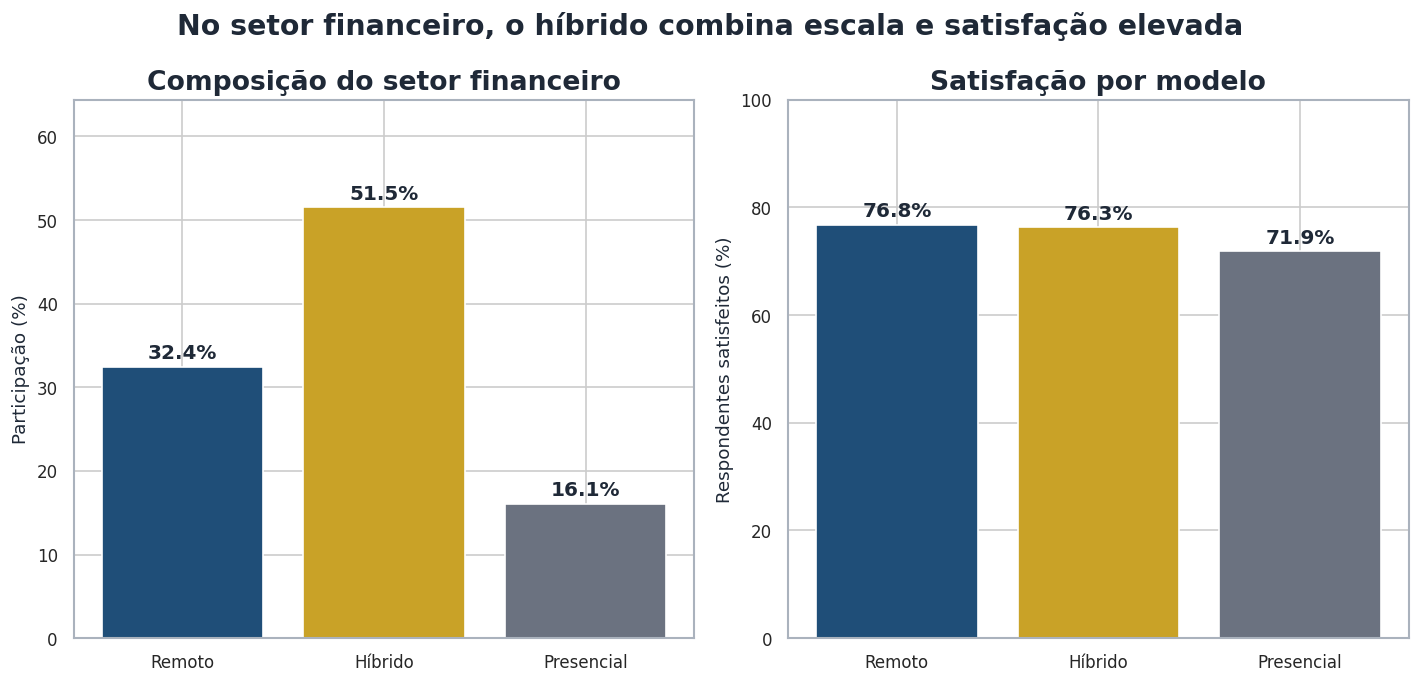

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/14_modelo_trabalho_satisfacao_financeiro.png


,participacao_pct,satisfacao_pct,respostas_satisfacao
modelo_trabalho_resumo,,,
Remoto,32.4,76.8,194
Híbrido,51.5,76.3,308
Presencial,16.1,71.9,96


In [26]:
# Calcula composição e satisfação por modelo de trabalho no setor financeiro em 2025
modelos_comparaveis = ["Remoto", "Híbrido", "Presencial"]
financeiro_2025 = df_modelo_trabalho[
    (df_modelo_trabalho["ano_pesquisa"].eq(ANO_REFERENCIA)) &
    (df_modelo_trabalho["setor"].eq(SETOR_FINANCEIRO)) &
    (df_modelo_trabalho["modelo_trabalho_resumo"].isin(modelos_comparaveis))
].copy()

mix_modelo = financeiro_2025["modelo_trabalho_resumo"].value_counts(normalize=True).mul(100).reindex(modelos_comparaveis)
satisfacao_modelo = (
    financeiro_2025.dropna(subset=["satisfeito"])
    .groupby("modelo_trabalho_resumo")["satisfeito"].agg(["mean", "count"])
    .reindex(modelos_comparaveis)
)
satisfacao_modelo["satisfacao_pct"] = 100 * satisfacao_modelo["mean"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.8))
cores_modelo = [CORES["azul"], CORES["dourado"], CORES["cinza"]]
axes[0].bar(mix_modelo.index, mix_modelo.values, color=cores_modelo)
axes[0].set_title("Composição do setor financeiro")
axes[0].set_ylabel("Participação (%)")
axes[0].set_ylim(0, max(mix_modelo.values) * 1.25)
for i, v in enumerate(mix_modelo.values): axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

axes[1].bar(satisfacao_modelo.index, satisfacao_modelo["satisfacao_pct"], color=cores_modelo)
axes[1].set_title("Satisfação por modelo")
axes[1].set_ylabel("Respondentes satisfeitos (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(satisfacao_modelo["satisfacao_pct"]): axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")

fig.suptitle("No setor financeiro, o híbrido combina escala e satisfação elevada", fontsize=17, fontweight="bold")
salvar_grafico("14_modelo_trabalho_satisfacao_financeiro.png")

display(pd.DataFrame({"participacao_pct": mix_modelo, "satisfacao_pct": satisfacao_modelo["satisfacao_pct"], "respostas_satisfacao": satisfacao_modelo["count"]}).round(1))


## 14.7 Representação e diferença salarial por gênero no setor financeiro

A presença feminina permanece minoritária em todas as senioridades e existem diferenças salariais descritivas em 2025. As comparações não controlam cargo específico, região, experiência, empresa ou responsabilidade e, portanto, não comprovam causalidade ou discriminação.


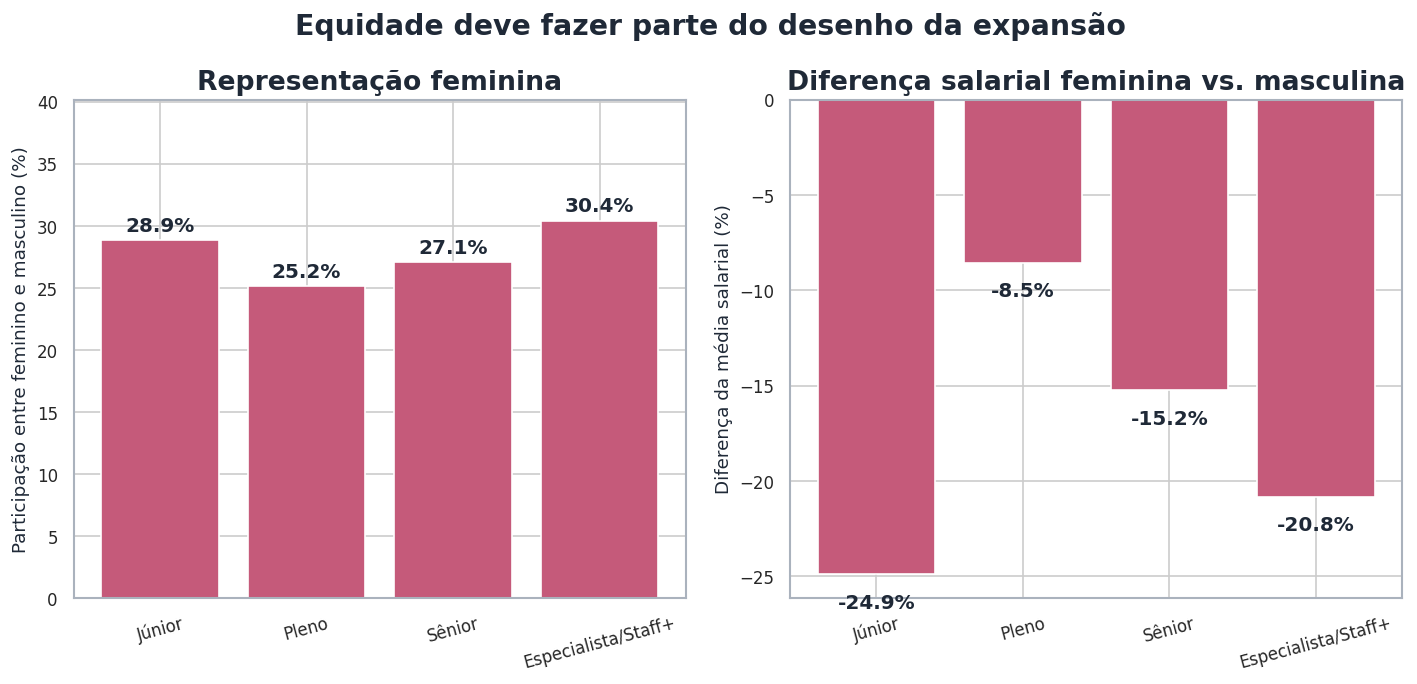

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/15_genero_setor_financeiro.png


,feminino_pct,diferenca_feminina_vs_masculina_pct,n_feminino,n_masculino
senioridade,,,,
Júnior,28.9,-24.9,28,69
Pleno,25.2,-8.5,34,101
Sênior,27.1,-15.2,52,140
Especialista/Staff+,30.4,-20.8,21,48


In [27]:
# Calcula representação feminina e diferença salarial dentro de cada senioridade
genero_fin_2025 = df_remuneracao[
    (df_remuneracao["ano_pesquisa"].eq(ANO_REFERENCIA)) &
    (df_remuneracao["setor"].eq(SETOR_FINANCEIRO)) &
    (df_remuneracao["genero"].isin(["Feminino", "Masculino"])) &
    (df_remuneracao["senioridade"].isin(ordem_senioridade_fin))
].copy()

representacao = pd.crosstab(genero_fin_2025["senioridade"], genero_fin_2025["genero"])
representacao["feminino_pct"] = 100 * representacao["Feminino"] / representacao.sum(axis=1)

salario_genero = genero_fin_2025.pivot_table(
    index="senioridade", columns="genero", values="salario_representativo",
    aggfunc=["mean", "count"]
)
gap_genero = pd.DataFrame(index=salario_genero.index)
gap_genero["diferenca_feminina_vs_masculina_pct"] = 100 * (
    salario_genero[("mean", "Feminino")] / salario_genero[("mean", "Masculino")] - 1
)
gap_genero["n_feminino"] = salario_genero[("count", "Feminino")]
gap_genero["n_masculino"] = salario_genero[("count", "Masculino")]

resumo_genero = representacao[["feminino_pct"]].join(gap_genero).reindex(ordem_senioridade_fin)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.8))
axes[0].bar(resumo_genero.index, resumo_genero["feminino_pct"], color=CORES["rosa"])
axes[0].set_title("Representação feminina")
axes[0].set_ylabel("Participação entre feminino e masculino (%)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].set_ylim(0, max(resumo_genero["feminino_pct"]) * 1.32)
for i, v in enumerate(resumo_genero["feminino_pct"]): axes[0].text(i, v + 0.7, f"{v:.1f}%", ha="center", fontweight="bold")

cores_gap = [CORES["rosa"] if v < 0 else CORES["verde"] for v in resumo_genero["diferenca_feminina_vs_masculina_pct"]]
axes[1].bar(resumo_genero.index, resumo_genero["diferenca_feminina_vs_masculina_pct"], color=cores_gap)
axes[1].axhline(0, color=CORES["texto"], linewidth=1)
axes[1].set_title("Diferença salarial feminina vs. masculina")
axes[1].set_ylabel("Diferença da média salarial (%)")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(resumo_genero["diferenca_feminina_vs_masculina_pct"]):
    axes[1].text(i, v - 1 if v < 0 else v + 0.5, f"{v:.1f}%", ha="center", va="top" if v < 0 else "bottom", fontweight="bold")

fig.suptitle("Equidade deve fazer parte do desenho da expansão", fontsize=17, fontweight="bold")
salvar_grafico("15_genero_setor_financeiro.png")

display(resumo_genero.round(1))


## 14.8 Roadmap executivo de implementação

As evidências sustentam uma expansão em três horizontes: definir a estrutura e a governança, formar o núcleo crítico e escalar capacidades com monitoramento contínuo.


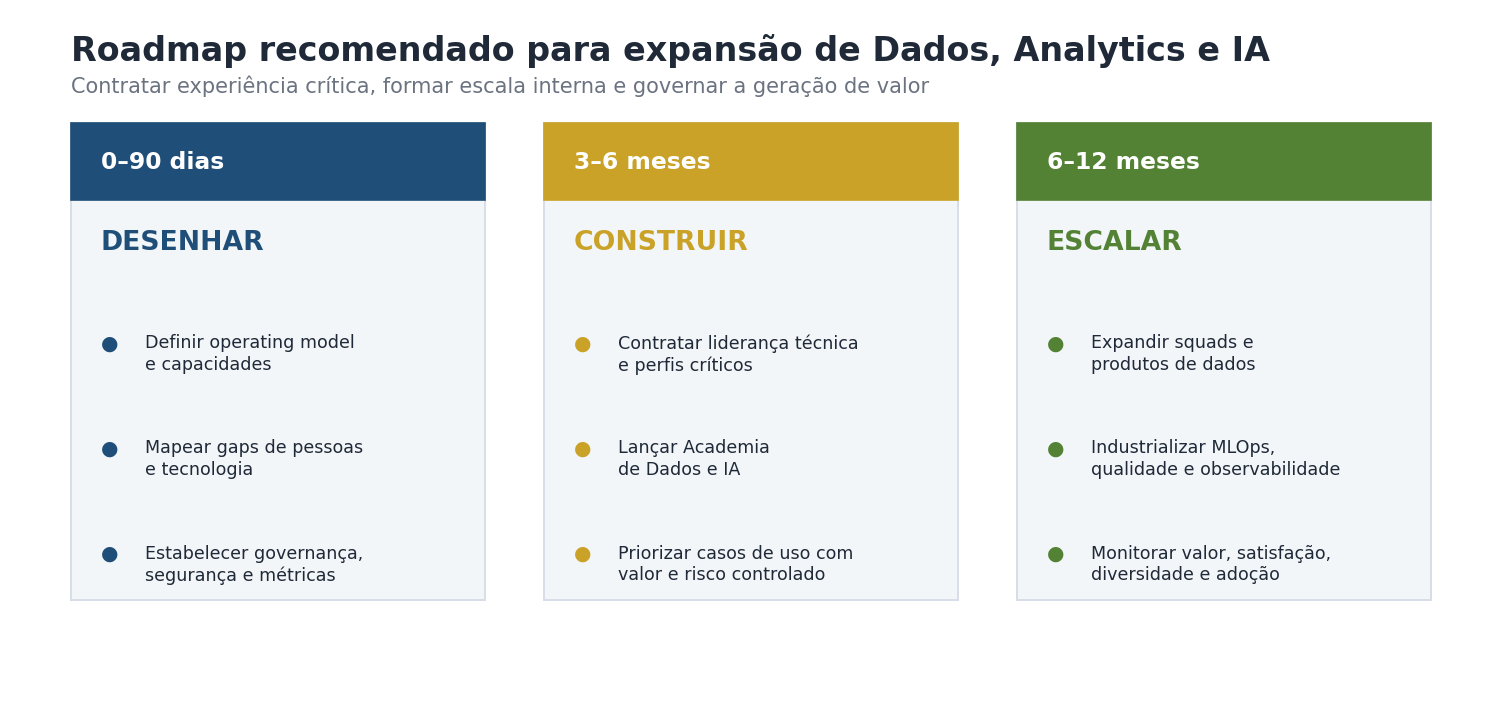

Gráfico salvo em: /content/drive/MyDrive/Projeto FIAP/Tech Challenge Fase 3/outputs/graficos_gold/16_roadmap_executivo_instituicao_financeira.png


In [28]:
# Cria um roadmap executivo em formato reutilizável no material final
fig, ax = plt.subplots(figsize=(13, 6.2))
ax.axis("off")

fases = [
    ("0–90 dias", "DESENHAR", CORES["azul"], [
        "Definir operating model\ne capacidades", "Mapear gaps de pessoas\ne tecnologia",
        "Estabelecer governança,\nsegurança e métricas"
    ]),
    ("3–6 meses", "CONSTRUIR", CORES["dourado"], [
        "Contratar liderança técnica\ne perfis críticos", "Lançar Academia\nde Dados e IA",
        "Priorizar casos de uso com\nvalor e risco controlado"
    ]),
    ("6–12 meses", "ESCALAR", CORES["verde"], [
        "Expandir squads e\nprodutos de dados", "Industrializar MLOps,\nqualidade e observabilidade",
        "Monitorar valor, satisfação,\ndiversidade e adoção"
    ]),
]

for i, (periodo, titulo, cor, acoes) in enumerate(fases):
    x = 0.04 + i * 0.32
    ax.add_patch(plt.Rectangle((x, 0.16), 0.28, 0.68, facecolor="#F3F6F9", edgecolor="#D7DEE7", linewidth=1.2))
    ax.add_patch(plt.Rectangle((x, 0.73), 0.28, 0.11, facecolor=cor, edgecolor=cor))
    ax.text(x + 0.02, 0.785, periodo, color="white", fontsize=14, fontweight="bold", va="center")
    ax.text(x + 0.02, 0.66, titulo, color=cor, fontsize=16, fontweight="bold")
    for j, acao in enumerate(acoes):
        y = 0.54 - j * 0.15
        ax.text(x + 0.02, y, "●", color=cor, fontsize=12, va="top")
        ax.text(x + 0.05, y, acao, color=CORES["texto"], fontsize=10.5, va="top", linespacing=1.25)

ax.text(0.04, 0.93, "Roadmap recomendado para expansão de Dados, Analytics e IA", fontsize=20, fontweight="bold", color=CORES["texto"])
ax.text(0.04, 0.885, "Contratar experiência crítica, formar escala interna e governar a geração de valor", fontsize=12.5, color=CORES["cinza"])
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
salvar_grafico("16_roadmap_executivo_instituicao_financeira.png")


## 15. Recomendações estratégicas para a Instituição Financeira

### 1. Estruturar a expansão por capacidades
Organizar a área em três núcleos complementares: **Data Foundation**, **Analytics & Decision** e **AI & Advanced Analytics**, com governança transversal. A composição observada no setor demonstra que análise, ciência, engenharia e tradução de negócio precisam coexistir.

### 2. Combinar contratação seletiva e formação interna
Priorizar contratação externa para liderança técnica, arquitetura, engenharia, Staff/Especialistas, ML Engineering e governança. Criar uma academia interna para desenvolver Analistas de Dados, BI, Analytics Engineering, SQL, Python e conhecimento do negócio financeiro.

### 3. Colocar Cloud, Python e IA governada no centro da capacitação
SQL e BI permanecem como fundamentos. Entretanto, Python atinge 92,7% e AWS 67,7% no setor financeiro em 2025. IA para produtividade chega a 97,9%, mas esse indicador não comprova maturidade em produção. A trilha deve incluir engenharia, MLOps, segurança, privacidade, explicabilidade e risco de modelos.

### 4. Construir uma proposta de valor competitiva
Definir faixas por senioridade e capacidade crítica, carreira técnica clara, aprendizagem contínua e modelo híbrido flexível. Em 2025, a satisfação no setor financeiro foi praticamente igual entre remoto e híbrido.

### 5. Incorporar equidade desde o desenho da expansão
Monitorar representação, remuneração, contratação, promoção e permanência por gênero e senioridade. As diferenças observadas são descritivas, mas justificam controles preventivos e critérios transparentes.


## 16. Arquivos gerados

Os gráficos são salvos automaticamente em `outputs/graficos_gold` no repositório ou em `Tech_Challenge_Fase_3/outputs/graficos_gold` no Google Drive. Eles podem ser utilizados diretamente na apresentação executiva.

In [29]:
# Lista os gráficos exportados para conferência final
graficos_gerados = sorted(OUTPUT_DIR.glob("*.png"))

# Exibe nome e tamanho de cada arquivo
arquivos_saida = pd.DataFrame([
    {
        "arquivo": grafico.name,
        "tamanho_kb": round(grafico.stat().st_size / 1024, 1),
    }
    for grafico in graficos_gerados
])

display(arquivos_saida)
print(f"Total de gráficos gerados: {len(graficos_gerados)}")

,arquivo,tamanho_kb
0,01_panorama_salario_satisfacao.png,179.3
1,02_evolucao_tecnologias.png,155.5
2,03_adocao_ia_produtividade.png,84.1
3,04_remuneracao_senioridade.png,89.5
4,05_composicao_modelo_trabalho.png,95.6
5,06_satisfacao_salario_modelo.png,206.7
6,07_remuneracao_genero_senioridade.png,92.8
7,08_top_cargos.png,119.9
8,09_participacao_principais_setores.png,166.6
9,10_composicao_cargos_setor_financeiro.png,143.6


Total de gráficos gerados: 16


## Conclusão

O setor financeiro já constitui um dos maiores polos de profissionais de dados da amostra e combina alta maturidade técnica, forte presença de profissionais experientes e adoção de Cloud acima do mercado geral. Para competir nesse ambiente, a Instituição Financeira deve evitar uma expansão baseada apenas em volume de contratações.

A estratégia recomendada é formar uma estrutura multidisciplinar, contratar seletivamente experiência crítica, criar escala por capacitação interna e sustentar a expansão com Cloud, Python, IA governada, carreira técnica, flexibilidade e controles de equidade. A arquitetura AWS e as tabelas Gold garantem rastreabilidade e reprodutibilidade às evidências utilizadas.
